# §5.3 — Mezclas binarias: superposición, brecha de Jensen y medio efectivo

Estudio de mezclas binarias RGD ($r_1 = 75$ nm, $r_2 = 35$ nm) a $\mu_s$ total fijo.
El pipeline homogéneo de referencia es el de `particles.ipynb` (§5.1): mismo stitching,
misma baseline, mismas métricas. Aquí se implementa el **protocolo completo** de la
sección de mezclas:

**Observable central.** La superposición se define al nivel de **intensidades**
(cociente de promedios, no promedio de cocientes):

$$\eta_{\rm sup}(\theta;x) = \frac{x\,I_1(\theta) + (1-x)\,I_2(\theta)}{x\,B_1(\theta) + (1-x)\,B_2(\theta)},\qquad
\Delta(\theta;x) \equiv \eta_{\rm mix}(\theta;x) - \eta_{\rm sup}(\theta;x).$$

$\eta_{\rm sup}$ es la hipótesis nula (segregación macroscópica: las especies nunca
comparten trayectoria); $\Delta$ es la firma del entrelazamiento de especies a nivel
de camino. La expansión de Jensen a 2º orden en $(s_1-s_2)$, con $s \equiv 1/\ell^* = \mu_s(1-g)$:

$$\Delta(\theta;x) \approx -\tfrac{1}{2}\,x(1-x)\,(s_1-s_2)^2\,
\partial_s^2\!\left[F(k\theta/s)\right]_{s=s_{\rm eff}},\qquad s_{\rm eff}(x) = x s_1 + (1-x) s_2,$$

predice: **(i)** $\Delta \propto x(1-x)$ a $\theta$ fijo; **(ii)** $\Delta \propto (s_1-s_2)^2$
(citada, no barrida aquí); **(iii)** $\Delta(0)=0$, extremo a $q$ intermedio, decaimiento en las alas.

**Protocolo (Pasos 0–6):** convenciones fijadas de antemano → campaña ($x\in$ malla, $R=5$
réplicas) → perfiles por réplica ($\sum C/\sum I$ por bin) → $\eta_{\rm sup}$ por réplica desde
acumuladores crudos, pareando índices → $\bar\Delta(\theta;x) \pm t_{0.975,4}\,s_\Delta/\sqrt{5}$ →
escalares y ajustes (RMS $= A\,x(1-x)$, signo de $\Delta_{\rm ext}$) → tests de aditividad
complementarios (FWHM lineal en $x$, colapso en $q$, $\rho(x)$ aditiva, reciprocidad).


In [1]:
import sys
import os
sys.path.append(os.path.abspath("../../"))

In [2]:
from utils.loaders import load_sweep
from utils.styles import apply, TEXTWIDTH_IN, DOC_FONTSIZE, COL
from utils.analysis import cbs_profiles, linear, circular, keep, phi_cut, azimuthal_average

import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from dataclasses import dataclass
import pandas as pd

@dataclass
class Grouped:
    name: str
    fraction: float
    replicas_keys: list[str]

In [3]:
import pathlib
FIGDIR = pathlib.Path("figs_tesis")
FIGDIR.mkdir(exist_ok=True)

In [4]:
save_path = "/Users/niaggar/Results"
fraction_list = np.linspace(0.0, 1.0, 11)
N_MEDIUM = 1.33
WAVELENGTH = 0.514 
k = 2 * np.pi * N_MEDIUM / WAVELENGTH
N_REPLICAS = 5


## Paso 0 — Convenciones fijadas de antemano

Idénticas para extremos y mezclas (cualquier asimetría de procesamiento contamina $\Delta$):

- **Canal primario:** lineal co-polarizado, corte $\phi=0$ (la dilución simple vive ahí y es parte de la física).
- **Control de reciprocidad:** circular helicidad conservada $h\parallel h$ (= `cross` en la convención del código), con la reserva del sesgo $+0.067$ del canal cruzado hasta resolverlo.
- **Ventana de $q$ para escalares del ápice:** criterio de punta $q_{\max}\approx 2$ (§5.1).
- **Ventana angular del residual:** $\theta \in [0.4,\,6.0]$ mrad (cono, sin el ápice ruidoso).
- **Línea base:** mediana de cola (`tail_baseline`), calculada **por perfil, antes de restar nada** — nunca la de la mezcla aplicada a la superposición ni viceversa (offset espurio $\sim 1\%$, del orden del efecto).
- **Incertidumbre:** por réplica, $\pm t_{0.975,\,n-1}\,s/\sqrt{n}$ ($t=2.78$ para $n=5$). Nunca ajustes por bin con errores de `curve_fit` (correlación angular del next-event estimator).
- **La superposición solo está definida en $\theta$ físico**: los extremos tienen $\ell^*$ distintos y sus $q_i = k\ell_i^*\theta$ no son conmensurables. Se construye $\eta_{\rm sup}(\theta)$ primero y se pasa a $q$ (con $\ell^*_{\rm eff}$) solo para presentar.


In [5]:
# ===========================================================================
# Paso 0 -- convenciones del analisis (fijadas antes de tocar datos)
# ===========================================================================
from scipy import stats

CONV = dict(
    canal_primario   = ("linear", "co"),     # lineal co-polarizado, phi = 0
    canal_control    = ("circular", "cross"),# helicidad conservada h||h
    phi_main         = 0,                    # corte phi = 0 (X-scan)
    q_max_apice      = 2.0,                  # ventana de escalares del apice (criterio de punta, 5.1)
    w_mrad_residual  = (0.4, 6.0),           # ventana angular fija del residual Delta
    q_min_baseline   = 25.0,                 # mediana de cola (tail_baseline), por perfil
    smooth_bins      = 7,                    # suavizado SOLO para localizar extremos/cruces
    conf             = 0.975,                # dos colas al 95%
)

def t_ci(n, conf=CONV["conf"]):
    """Factor t de Student para el IC de la media sobre n replicas."""
    return stats.t.ppf(conf, n - 1)

print(f"t_(0.975, 4) = {t_ci(5):.3f}   (n = {N_REPLICAS} replicas)")

# --- forma del cono difusivo (Akkermans et al. 1986), misma que particles.ipynb ---
B_MILNE = 0.7104          # z0/l*, condicion de contorno de Milne

def cone_shape(u, b=B_MILNE):
    """Cono difusivo normalizado, C(0) = 1."""
    u = np.maximum(np.asarray(u, float), 1e-9)
    return (1.0/(1.0 + 2.0*b)) / (1.0 + u)**2 * (1.0 + (1.0 - np.exp(-2.0*b*u)) / u)


t_(0.975, 4) = 2.776   (n = 5 replicas)


# Linear Polarization study of RGD particles

In [6]:
folder_lineal = "study_mixture_layer__PLIN__beam2500"
sweep_data_lineal = load_sweep(folder_lineal, base_path=Path(save_path))

data_keys = list(sweep_data_lineal.keys())
print(f"Loaded {len(data_keys)} datasets: {data_keys}")


grouped_data_lineal = []
for frac in fraction_list:
    replicas_keys = [key for key in data_keys if f"fraction_{frac:.2f}" in key]
    grouped = Grouped(fraction=frac, replicas_keys=replicas_keys, name=rf"{frac:.2f}")
    grouped_data_lineal.append(grouped)

print(grouped_data_lineal)


Loaded 60 datasets: ['0017_fraction_0.30__rep2', '0058_matched_ref_r0.035__rep3', '0023_fraction_0.40__rep3', '0009_fraction_0.10__rep4', '0008_fraction_0.10__rep3', '0022_fraction_0.40__rep2', '0049_fraction_0.90__rep4', '0026_fraction_0.50__rep1', '0025_fraction_0.50__rep0', '0011_fraction_0.20__rep1', '0048_fraction_0.90__rep3', '0010_fraction_0.20__rep0', '0024_fraction_0.40__rep4', '0051_fraction_1.00__rep1', '0036_fraction_0.70__rep1', '0035_fraction_0.70__rep0', '0001_fraction_0.00__rep1', '0000_fraction_0.00__rep0', '0047_fraction_0.90__rep2', '0034_fraction_0.60__rep4', '0050_fraction_1.00__rep0', '0056_matched_ref_r0.035__rep1', '0040_fraction_0.80__rep0', '0007_fraction_0.10__rep2', '0033_fraction_0.60__rep3', '0059_matched_ref_r0.035__rep4', '0019_fraction_0.30__rep4', '0041_fraction_0.80__rep1', '0018_fraction_0.30__rep3', '0032_fraction_0.60__rep2', '0016_fraction_0.30__rep1', '0021_fraction_0.40__rep1', '0015_fraction_0.30__rep0', '0020_fraction_0.40__rep0', '0014_fracti

In [7]:
eps = 1e-30

def load_stitched(channel, k, lstar, th1, g1, th2, g2, key):
    theta_1 = th1[-1]                       # fin de la ventana fina
    lo = 0.9 * theta_1                       # inicio real de det_2 (solape)

    # --- chequeo de stitching: interpola det_1 sobre los bins de solape de det_2
    ov = (th2 >= lo) & (th2 <= theta_1)
    if ov.any():
        g1_on2 = np.interp(th2[ov], th1, g1)
        resid = np.abs(g2[ov] - g1_on2)
        if np.max(resid) > 0.05:            # umbral: 5% del enhancement
            print(f"[stitch WARN] {key} ch={channel}: max solape "
                  f"{np.max(resid):.3f} -- revisar normalizacion angulo solido")

    # une: det_1 completo + det_2 estrictamente por encima de theta_1
    keep2 = th2 > theta_1
    theta = np.concatenate([th1, th2[keep2]])
    g = np.concatenate([g1, g2[keep2]])
    q = k * lstar * theta
    return theta, q, g

def tail_baseline(q, y, q_min=25.0, n_min=5, frac=0.85):
    """Fondo en la cola, inmune a ventanas vacías.
    Usa q>q_min si hay puntos suficientes; si no, cae al tramo alto
    del q realmente disponible para ese radio."""
    q = np.asarray(q); y = np.asarray(y)
    m = q > q_min
    if np.count_nonzero(m) >= n_min:
        return np.median(y[m])
    q_cut = frac * np.nanmax(q)          # último ~15 % del q disponible
    m = q >= q_cut
    if np.count_nonzero(m) < n_min:
        idx = np.argsort(q)[-n_min:]     # los n_min puntos de mayor q
        return np.median(y[idx])
    return np.median(y[m])

def load_mean_enhancement(grouped_rad, basis, reduce, time_index, chanel, k):
    I_incoherent_total_1 = None
    I_incoherent_total_2 = None
    I_coherent_total_1 = None
    I_coherent_total_2 = None
    for key in grouped_rad.replicas_keys:
        sweep = sweep_data_lineal[key]

        p1 = cbs_profiles(sweep.processed_cbs("farfield_cbs_1"), basis=basis, time_index=time_index, reduce=reduce)
        p2 = cbs_profiles(sweep.processed_cbs("farfield_cbs_2"), basis=basis, time_index=time_index, reduce=reduce)

        if I_incoherent_total_1 is None:
            I_incoherent_total_1 = np.zeros_like(p1.incoherent[chanel])
            I_incoherent_total_2 = np.zeros_like(p2.incoherent[chanel])
            I_coherent_total_1 = np.zeros_like(p1.coherent[chanel])
            I_coherent_total_2 = np.zeros_like(p2.coherent[chanel])

        I_incoherent_total_1 = I_incoherent_total_1 + p1.incoherent[chanel]
        I_incoherent_total_2 = I_incoherent_total_2 + p2.incoherent[chanel]
        I_coherent_total_1 = I_coherent_total_1 + p1.coherent[chanel]
        I_coherent_total_2 = I_coherent_total_2 + p2.coherent[chanel]

    enhancement_1 = (I_coherent_total_1 + eps) / (I_incoherent_total_1 + eps)
    enhancement_2 = (I_coherent_total_2 + eps) / (I_incoherent_total_2 + eps)
    sweep0 = sweep_data_lineal[grouped_rad.replicas_keys[0]]
    p0_1 = cbs_profiles(sweep0.processed_cbs("farfield_cbs_1"), basis=basis, time_index=time_index, reduce=reduce)
    p0_2 = cbs_profiles(sweep0.processed_cbs("farfield_cbs_2"), basis=basis, time_index=time_index, reduce=reduce)
    theta_1 = p0_1.theta
    theta_2 = p0_2.theta

    lstar0 = sweep_data_lineal[grouped_rad.replicas_keys[0]].params_flat["transport_mean_free_path"]
    theta, q, enhancement = load_stitched(chanel, k, lstar0, theta_1, enhancement_1, theta_2, enhancement_2, grouped_rad.replicas_keys[0])

    return theta, q, enhancement

PHI_DEG = {0: 0, 1: 45, 2: 90}   # indices de set_phi_slices([0, pi/4, pi/2])

def get_profile(grouped_rad, phi_index, channel, time_index=0):
    """Perfil E(q) promediado sobre replicas, con baseline llevada a 1."""
    _, q, E = load_mean_enhancement(grouped_rad, linear, phi_cut(phi_index),
                                    time_index, channel, k)
    base = tail_baseline(q, E, q_min=25.0)
    return q, E - base + 1.0

def peak_height(q, E, n=3):
    """E(0) estimado como mediana de los primeros n bins (robusto al ruido del apice)."""
    return np.median(E[:n])

def fwhm_q(q, E, n=3):
    """Ancho total a mitad de altura en unidades de q, por interpolacion lineal."""
    E0 = peak_height(q, E, n)
    half = 1.0 + 0.5 * (E0 - 1.0)
    below = np.where(E < half)[0]
    if len(below) == 0:
        return np.nan
    i = below[0]                                  # primer bin bajo el semi-maximo
    # interpolacion entre (i-1, i):
    q_half = q[i-1] + (half - E[i-1]) * (q[i] - q[i-1]) / (E[i] - E[i-1])
    return 2.0 * q_half                            # cono simetrico en theta

def profile_one(sweep, key, phi_index, channel, time_index=0, basis=linear):
    """Perfil E(q) de UNA replica, baseline llevada a 1."""
    reducer = phi_cut(phi_index) if basis == linear else azimuthal_average
    sw = sweep[key]
    p1 = cbs_profiles(sw.processed_cbs("farfield_cbs_1"), basis=basis,
                      time_index=time_index, reduce=reducer)
    p2 = cbs_profiles(sw.processed_cbs("farfield_cbs_2"), basis=basis,
                      time_index=time_index, reduce=reducer)
    E1 = (p1.coherent[channel] + eps) / (p1.incoherent[channel] + eps)
    E2 = (p2.coherent[channel] + eps) / (p2.incoherent[channel] + eps)
    lst = sw.params_flat["transport_mean_free_path"]
    _, q, E = load_stitched(channel, k, lst, p1.theta, E1, p2.theta, E2, key)
    return q, E - tail_baseline(q, E) + 1.0

def profile_stats(sweep, grouped_rad, phi_index, channel, time_index=0, basis=linear):
    """Media y desviacion estandar (ddof=1) sobre las replicas."""
    curves = []
    for key in grouped_rad.replicas_keys:
        q, E = profile_one(sweep, key, phi_index, channel, time_index=time_index, basis=basis)
        curves.append(E)
    C = np.vstack(curves)
    return q, C.mean(axis=0), C.std(axis=0, ddof=1)

def mirror(q, *ys):
    """Espejo -q..+q para presentacion estilo Iwai (valido: I(th,phi)=I(th,phi+pi))."""
    return (np.r_[-q[::-1], q],) + tuple(np.r_[y[::-1], y] for y in ys)

In [8]:
def leyenda_inferior(fig, ax, ncol=6):
    fig.legend(*ax.get_legend_handles_labels(),
               ncol=ncol, loc="outside lower center",
               frameon=False, columnspacing=1.2, handlelength=1.3)

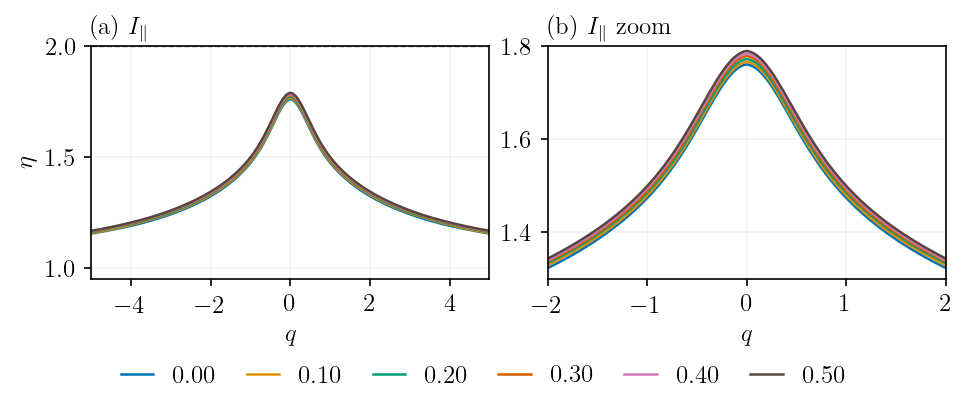

In [9]:
apply(width_frac=1.0)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(TEXTWIDTH_IN, 0.42*TEXTWIDTH_IN), sharey=False)

for c, g_ in zip(COL, grouped_data_lineal):
    q, m, s = profile_stats(sweep_data_lineal, g_, 0, "co", time_index=0, basis=linear)          # phi = 0 (X-scan)
    qs, ms, ss = mirror(q, m, s)

    ax1.plot(qs, ms, color=c, label=g_.name)
    ax2.plot(qs, ms, color=c, label=g_.name)


for ax, t in ((ax1, "(a) $I_\\parallel$"), (ax2, "(b) $I_\\parallel$ zoom")):
    ax.set_xlim(-5, 5)
    ax.set_ylim(0.95, 2.0)
    ax.set_xlabel(r"$q$")
    ax.grid(alpha=0.15)

ax1.set_ylabel(r"$\eta$")
ax1.axhline(2.0, ls="--", c="gray", lw=0.7)

ax2.set_xlim(-2, 2)
ax2.set_ylim(1.3, 1.8)

ax1.set_title("(a) $I_\\parallel$", loc="left")
ax2.set_title("(b) $I_\\parallel$ zoom", loc="left")
leyenda_inferior(fig, ax1, ncol=6)
fig.savefig(FIGDIR / "cbs_perfiles_co_cross.pdf")
plt.show()

# Análisis §5.3 — Mezclas binarias (figuras de tesis)

Mapa de bloques (mismo plan que el LaTeX; todo es postprocesado, ninguna simulación nueva):

| Bloque | Paso | Produce | Archivo |
|---|---|---|---|
| Config  | 0–2 | carga circular, canales, $\ell^*(x)$, $s(x)$, $g_{\rm eff}$ | — |
| Gate    | — | extremos $x=0,1$ vs homogéneas ($\chi^2$/bin) | `gate_extremos_{base}.pdf` |
| **F10** | 6 | familia $\eta(\theta;x)$ + colapso $q=k\ell^*(x)\theta$ | `F10_perfil_familia.pdf` |
| **F11** | 6 | $\theta_{\rm FWHM}(x)$ y $\eta(0)(x)$ + predicciones | `F11_observables_vs_x.pdf` |
| **F12** | 3–4 | superposición a nivel de **intensidades** en $x=0.5$, $\Delta \pm t\,{\rm SE}$ | `F12_superposicion_{base}.pdf` |
| **F13** | 4 | familia $\bar\Delta(\theta;x)$ + chequeo $\Delta(0)=0$ | `F13_delta_familia_{base}.pdf` |
| **F12b**| 5 | escalado $x(1-x)$: RMS, $\Delta_{\rm ext}$, $q_{\rm ext}$ | `F12b_escalado_x1mx.pdf` |
| **F14** | 2 | predicción de curvatura (Jensen sobre la forma AWM) vs $\bar\Delta$ | `F14_jensen_pred_{base}.pdf` |
| Paso 6  | 6 | FWHM lineal en $x$, colapso en $q$, $\rho(x)$, reciprocidad | consola + `F15_paso6.pdf` |
| Tabla   | — | degeneración $(x,\ell^*,{\rm FWHM},E_0,\rho)$ | `tabla_degeneracion.csv/.tex` |

Convenciones: canal principal **lineal = `co`** (corte $\phi=0$, como en §5.1);
**circular = helicidad conservada = `cross`** en la convención del código (bajo inversión
de propagación la helicidad conservada aparece como cross-polarizado de laboratorio) —
la celda de configuración lo verifica imprimiendo $\eta(0)$ por canal. `time_index=0` =
señal integrada en tiempo.


In [10]:
# ===========================================================================
# §5.3 -- Configuración: barrido circular, canales, l*(x)
#   Requiere las celdas de utilidades de arriba (profile_one, load_stitched,
#   tail_baseline, fwhm_q, peak_height, ...).
# ===========================================================================
folder_circular = "study_mixture_layer__PCIR__beam2500"     # <-- ajusta al nombre real
sweep_data_circular = load_sweep(folder_circular, base_path=Path(save_path))
print(f"Loaded {len(sweep_data_circular.keys())} datasets (circular)")

grouped_data_circular = []
for frac in fraction_list:
    keys = sorted(k_ for k_ in sweep_data_circular.keys() if f"fraction_{frac:.2f}" in k_)
    grouped_data_circular.append(Grouped(fraction=frac, replicas_keys=keys,
                                         name=rf"$x={frac:.2f}$"))

# réplicas ordenadas también en lineal (el pareo réplica-a-réplica de F12 lo exige)
for g_ in grouped_data_lineal:
    g_.replicas_keys = sorted(g_.replicas_keys)
    g_.name = rf"$x={g_.fraction:.2f}$"

SWEEPS = {"linear": sweep_data_lineal, "circular": sweep_data_circular}
GROUPS = {"linear": grouped_data_lineal, "circular": grouped_data_circular}
BASIS  = {"linear": linear, "circular": circular}
# canal principal por base:
#   lineal   -> co-polarizado (corte phi=0)
#   circular -> helicidad conservada = 'cross' en la convención del código
CHANNELS = {"linear":   {"main": "co",    "aux": "cross"},
            "circular": {"main": "cross", "aux": "co"}}
PHI_MAIN = 0            # corte phi=0 (X-scan); en circular se usa azimuthal_average

# l*(x) teórico (derived_quantities_mixture) leído de params de la réplica 0
LSTAR = {b: np.array([float(SWEEPS[b][GROUPS[b][i].replicas_keys[0]]
                            .params_flat["transport_mean_free_path"])
                      for i in range(len(fraction_list))])
         for b in SWEEPS}
print("l*(x) [um] lineal  :", np.round(LSTAR["linear"], 3))
print("l*(x) [um] circular:", np.round(LSTAR["circular"], 3))

# sanity: los dos barridos deben reportar el mismo l*(x)
if not np.allclose(LSTAR["linear"], LSTAR["circular"], rtol=1e-6):
    print("[WARN] l*(x) difiere entre PLIN y PCIR: revisa las carpetas")

# verificación del canal de helicidad conservada: debe ser el de MAYOR pico (~2)
_gc = GROUPS["circular"][5]
for _ch in ("co", "cross"):
    _q, _E = profile_one(sweep_data_circular, _gc.replicas_keys[0], PHI_MAIN, _ch,
                         basis=circular)
    print(f"[circular x=0.50] canal '{_ch}': E(0) ~ {peak_height(_q, _E):.3f}")
print("-> si 'co' saliera mayor que 'cross', invierte CHANNELS['circular'].")

# --- s(x) = 1/l*(x): la variable natural del gap de Jensen -----------------
S_X   = 1.0 / LSTAR["linear"]                       # [1/um]
S1, S2 = S_X[-1], S_X[0]                            # especie 1 (x=1, 75 nm) y 2 (x=0, 35 nm)
s_eff_lin = fraction_list * S1 + (1 - fraction_list) * S2
print("max |s(x) - [x s1 + (1-x) s2]| / s =",
      f"{np.max(np.abs(S_X - s_eff_lin) / S_X):.2e}",
      " (debe ser ~0: s_eff es lineal en x por construccion)")

# --- anisotropia g por composicion (para la clausura C(g_eff)) -------------
def _g_of_run(sweep, key):
    p = sweep[key].params_flat
    return float(p["anisotropy_g_eff"]) if "anisotropy_g_eff" in p else np.nan

G_X = np.array([_g_of_run(sweep_data_lineal, g_.replicas_keys[0])
                for g_ in grouped_data_lineal])
print(G_X)
if np.any(np.isnan(G_X)):
    print("[WARN] g no encontrado en params_flat; fija G1, G2 a mano "
          "(derived_quantities de luminis_mc para r=75 y r=35 nm)")
    G1 = G2 = np.nan
else:
    G1, G2 = G_X[-1], G_X[0]
    print(f"g(x): {np.round(G_X, 4)}   ->  g1 = {G1:.4f} (75 nm), g2 = {G2:.4f} (35 nm)")



print(sweep_data_circular[grouped_data_lineal[0].replicas_keys[0]].params_flat)

Loaded 55 datasets (circular)
l*(x) [um] lineal  : [18.283 18.721 19.115 19.547 20.026 20.48  20.977 21.428 21.987 22.617
 23.091]
l*(x) [um] circular: [18.296 18.714 19.064 19.519 19.966 20.484 20.96  21.474 21.989 22.55
 23.165]
[WARN] l*(x) difiere entre PLIN y PCIR: revisa las carpetas
[circular x=0.50] canal 'co': E(0) ~ 1.380
[circular x=0.50] canal 'cross': E(0) ~ 1.989
-> si 'co' saliera mayor que 'cross', invierte CHANNELS['circular'].
max |s(x) - [x s1 + (1-x) s2]| / s = 5.23e-03  (debe ser ~0: s_eff es lineal en x por construccion)
[0.05084436 0.07305167 0.09216716 0.11223731 0.13345826 0.15266007
 0.17274785 0.19014151 0.21073987 0.23273157 0.24848102]
g(x): [0.0508 0.0731 0.0922 0.1122 0.1335 0.1527 0.1727 0.1901 0.2107 0.2327
 0.2485]   ->  g1 = 0.2485 (75 nm), g2 = 0.0508 (35 nm)
{'angular_anchor': 'x=0', 'anisotropy_g_eff': 0.05150036111250979, 'd_phi': 0.17453292519943295, 'd_theta_1': 0.00010049438128040218, 'd_theta_2': 0.0008932833891591305, 'd_time': 23.16615631911

In [11]:
# ===========================================================================
# Utilidades §5.3: perfiles en ángulo físico, intensidades (superposición
# naive) y observables por réplica.
#   ACTUALIZADO (protocolo Pasos 3-4): paired_residual devuelve tambien las
#   matrices por replica y el IC t-Student t_{0.975, n-1} * SE.
# ===========================================================================
def _profiles_raw(sweep, key, phi_index, channel, time_index, basis):
    reducer = phi_cut(phi_index) if basis == linear else azimuthal_average
    sw = sweep[key]
    p1 = cbs_profiles(sw.processed_cbs("farfield_cbs_1"), basis=basis,
                      time_index=time_index, reduce=reducer)
    p2 = cbs_profiles(sw.processed_cbs("farfield_cbs_2"), basis=basis,
                      time_index=time_index, reduce=reducer)
    return sw, p1, p2


def profile_one_theta(sweep, key, phi_index, channel, time_index=0, basis=linear):
    """Perfil de UNA réplica en ángulo físico theta [rad] y en q propio
    (q = k l*(x) theta, con el l* de ESE run); baseline llevada a 1."""
    sw, p1, p2 = _profiles_raw(sweep, key, phi_index, channel, time_index, basis)
    E1 = (np.asarray(p1.coherent[channel]) + eps) / (np.asarray(p1.incoherent[channel]) + eps)
    E2 = (np.asarray(p2.coherent[channel]) + eps) / (np.asarray(p2.incoherent[channel]) + eps)
    lst = float(sw.params_flat["transport_mean_free_path"])
    theta, q, E = load_stitched(channel, k, lst, np.asarray(p1.theta), E1,
                                np.asarray(p2.theta), E2, key)
    return theta, q, E - tail_baseline(q, E) + 1.0


def profile_stats_theta(sweep, grouped, phi_index, channel, time_index=0, basis=linear):
    """Media y sigma (ddof=1) del realce sobre réplicas; grilla compartida."""
    curves, theta, q = [], None, None
    for key in grouped.replicas_keys:
        theta, q, E = profile_one_theta(sweep, key, phi_index, channel, time_index, basis)
        curves.append(E)
    C = np.vstack(curves)
    return theta, q, C.mean(axis=0), C.std(axis=0, ddof=1)


def intensity_one(sweep, key, phi_index, channel, time_index=0, basis=linear):
    """(theta, I, B) de UNA réplica, ventanas fina+cola cosidas.
    I = intensidad total detectada (rama 'coherent' del postproceso),
    B = fondo incoherente. La superposición naive de Eq. (mix-naive) se
    construye con ESTAS cantidades, no con los realces: eta_sup =
    [x I_1 + (1-x) I_2] / [x B_1 + (1-x) B_2]."""
    sw, p1, p2 = _profiles_raw(sweep, key, phi_index, channel, time_index, basis)
    th1, th2 = np.asarray(p1.theta), np.asarray(p2.theta)
    keep2 = th2 > th1[-1]
    theta = np.concatenate([th1, th2[keep2]])
    I = np.concatenate([np.asarray(p1.coherent[channel], float),
                        np.asarray(p2.coherent[channel], float)[keep2]])
    B = np.concatenate([np.asarray(p1.incoherent[channel], float),
                        np.asarray(p2.incoherent[channel], float)[keep2]])
    return theta, I, B


def paired_residual(b, i_x, time_index=0):
    """Delta(theta; x) = eta_mix - eta_sup en la composición i_x, pareando
    réplica a réplica con los extremos x=0 y x=1 (misma grilla angular por
    diseño del script). eta_sup se construye desde los acumuladores CRUDOS
    (Paso 3): la baseline de cada perfil (mix y sup) se calcula por separado,
    ANTES de restar (trampa del offset espurio ~1%).

    Devuelve medias, SE e IC t-Student sobre réplicas, y las matrices por
    réplica para los escalares del Paso 5."""
    ch, bs = CHANNELS[b]["main"], BASIS[b]
    x = float(fraction_list[i_x])
    g0, g1, gt = GROUPS[b][0], GROUPS[b][-1], GROUPS[b][i_x]
    n = min(len(g0.replicas_keys), len(g1.replicas_keys), len(gt.replicas_keys))
    sims, nais, ress, theta = [], [], [], None
    for r in range(n):
        theta, I0, B0 = intensity_one(SWEEPS[b], g0.replicas_keys[r], PHI_MAIN, ch, time_index, bs)
        _,     I1, B1 = intensity_one(SWEEPS[b], g1.replicas_keys[r], PHI_MAIN, ch, time_index, bs)
        _,     It, Bt = intensity_one(SWEEPS[b], gt.replicas_keys[r], PHI_MAIN, ch, time_index, bs)
        q = k * LSTAR[b][i_x] * theta
        g_sup = (x * I1 + (1 - x) * I0 + eps) / (x * B1 + (1 - x) * B0 + eps)
        g_sim = (It + eps) / (Bt + eps)
        g_sup = g_sup - tail_baseline(q, g_sup) + 1.0     # baseline por perfil
        g_sim = g_sim - tail_baseline(q, g_sim) + 1.0
        sims.append(g_sim); nais.append(g_sup); ress.append(g_sim - g_sup)
    S, N_, R = (np.vstack(a) for a in (sims, nais, ress))
    se = R.std(0, ddof=1) / np.sqrt(n)
    tc = t_ci(n)
    return {"x": x, "n": n, "theta": theta, "q": k * LSTAR[b][i_x] * theta,
            "sim_mean": S.mean(0), "naive_mean": N_.mean(0),
            "res_mean": R.mean(0), "res_se": se, "res_ci": tc * se, "tcrit": tc,
            "sim_reps": S, "naive_reps": N_, "res_reps": R}


def residual_scalars(pr, w_mrad=None, smooth=None):
    """Paso 5: escalares POR REPLICA del residual sobre la ventana fija.
    - rms_r    : RMS crudo de Delta_r (incluye piso de ruido de esa replica)
    - ext_r    : extremo con signo del residual suavizado
    - thext_r  : posicion angular [mrad] del extremo
    - qext_r   : posicion en q = k l*_eff theta del extremo
    Devuelve tambien la 'señal' del perfil MEDIO (RMS con el piso de ruido
    restado en cuadratura), que es el estimador insesgado para el ajuste
    RMS(x) = A x(1-x)."""
    w_mrad = w_mrad or CONV["w_mrad_residual"]
    smooth = smooth or CONV["smooth_bins"]
    thm = pr["theta"] * 1e3
    m = (thm >= w_mrad[0]) & (thm <= w_mrad[1])
    kern = np.ones(smooth) / smooth
    rms_r, ext_r, thext_r, qext_r = [], [], [], []
    for row in pr["res_reps"]:
        rs = np.convolve(row, kern, mode="same")
        j = int(np.argmax(np.abs(rs[m])))
        rms_r.append(np.sqrt(np.mean(row[m] ** 2)))
        ext_r.append(rs[m][j]); thext_r.append(thm[m][j]); qext_r.append(pr["q"][m][j])
    rms_r, ext_r = np.asarray(rms_r), np.asarray(ext_r)
    thext_r, qext_r = np.asarray(thext_r), np.asarray(qext_r)
    # señal del perfil medio: RMS - piso (en cuadratura)
    rms_mean = np.sqrt(np.mean(pr["res_mean"][m] ** 2))
    floor    = np.sqrt(np.mean(pr["res_se"][m] ** 2))
    signal   = np.sqrt(max(rms_mean ** 2 - floor ** 2, 0.0))
    return {"m": m, "rms_reps": rms_r, "ext_reps": ext_r,
            "thext_reps": thext_r, "qext_reps": qext_r,
            "rms_mean": rms_mean, "floor": floor, "signal": signal}


def metric_over_replicas(sweep, grouped, phi_index, channel, basis, lstar):
    """(E0, sE0, theta_FWHM [mrad], sFWHM), error estándar sobre réplicas."""
    E0s, fws = [], []
    for key in grouped.replicas_keys:
        theta, q, E = profile_one_theta(sweep, key, phi_index, channel, basis=basis)
        E0s.append(peak_height(q, E))
        fws.append(fwhm_q(q, E) / (k * lstar) * 1e3)   # q = k l* theta
    E0s, fws, n = np.asarray(E0s), np.asarray(fws), len(E0s)
    return (E0s.mean(), E0s.std(ddof=1) / np.sqrt(n),
            np.nanmean(fws), np.nanstd(fws, ddof=1) / np.sqrt(n))


## Gate de extremos

Antes de cualquier física: los extremos del barrido deben reproducir medios homogéneos
al mismo $\mu_s$.

- $x=0$ vs la **referencia emparejada** (`matched_ref_r0.035`, misma carpeta, misma
  grilla, mismo $\ell_s$ forzado).
- $x=1$ vs la corrida homogénea de §5.1 con $r_1 = 75$ nm (opcional: requiere la carpeta
  del estudio homogéneo; $\mu_s$ idéntico por construcción del ancla del script).

Se comparan medias sobre réplicas; la banda es $\pm 2\sigma$ de la media combinada y se
reporta $\chi^2$/bin y RMS del residual (números citables para el texto y el Apéndice de
gates). También se verifica aquí la **trampa 3**: el depósito de dispersión simple debe
ser idéntico entre extremos y mezcla (el sesgo $+0.067$ del canal cruzado es exactamente
el tipo de inconsistencia que un observable de diferencia amplifica).


[gate x=0 vs matched_ref (lineal, co)] chi2/bin = 14032.97   RMS residual = 1.71e-01   max|res| = 2.63e-01


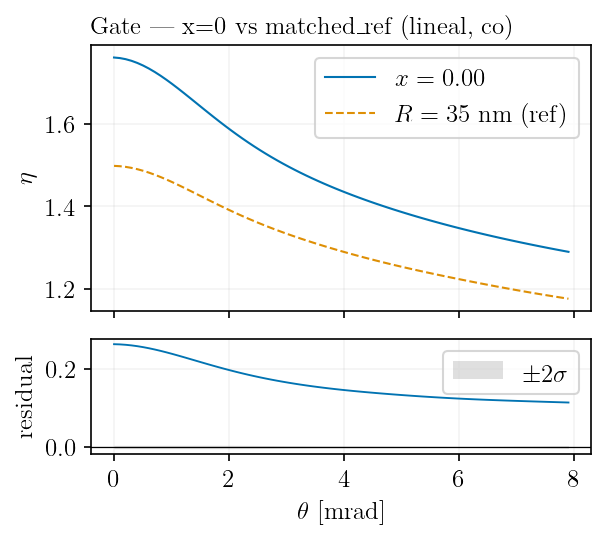

[gate x=1 vs homogenea 5.1 (lineal, co)] grillas distintas: interpolando B sobre A
[gate x=1 vs homogenea 5.1 (lineal, co)] chi2/bin = 1409.67   RMS residual = 4.28e-02   max|res| = 9.14e-02


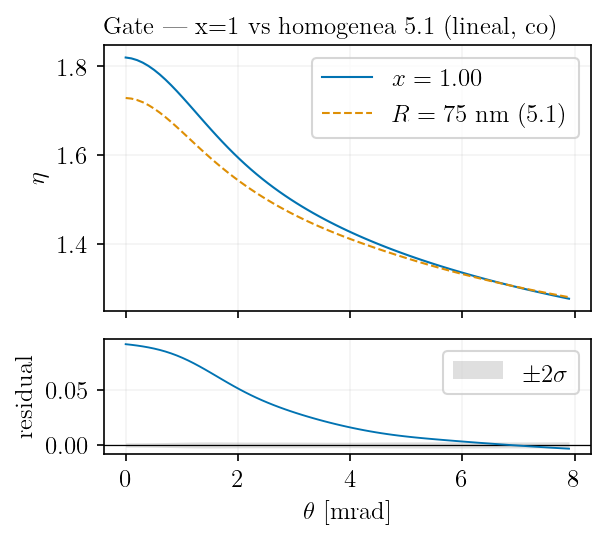

In [12]:
# ===========================================================================
# Gate de extremos: x=0 vs matched_ref (misma carpeta) y, opcional, x=1 vs
# la corrida homogenea de 5.1 (r = 75 nm).
# ===========================================================================
GATE_THETA_MAX = 8.0     # mrad

replicas_keys_ref_035 = sorted(key for key in data_keys if "matched_ref_r0.035" in key)
grouped_ref_035 = Grouped(fraction=0.00, replicas_keys=replicas_keys_ref_035,
                          name=r"$R=35$ nm (ref)")

def gate_compare(gA, gB, sweep, channel="co", basis=linear, label="", fname=None):
    """chi2/bin y RMS del residual entre las medias de dos grupos (misma grilla)."""
    thA, _, mA, sA = profile_stats_theta(sweep, gA, PHI_MAIN, channel, basis=basis)
    thB, _, mB, sB = profile_stats_theta(sweep, gB, PHI_MAIN, channel, basis=basis)
    if len(thA) != len(thB) or not np.allclose(thA, thB):
        mB = np.interp(thA, thB, mB); sB = np.interp(thA, thB, sB)
        print(f"[gate {label}] grillas distintas: interpolando B sobre A")
    nA, nB = len(gA.replicas_keys), len(gB.replicas_keys)
    seA, seB = sA / np.sqrt(nA), sB / np.sqrt(nB)
    se = np.sqrt(seA**2 + seB**2)
    thm = thA * 1e3
    w = thm <= GATE_THETA_MAX
    res = mA - mB
    z = res[w] / np.where(se[w] > 0, se[w], np.inf)
    chi2_bin = float(np.mean(z**2))
    rms      = float(np.sqrt(np.mean(res[w]**2)))
    print(f"[gate {label}] chi2/bin = {chi2_bin:.2f}   RMS residual = {rms:.2e}   "
          f"max|res| = {np.max(np.abs(res[w])):.2e}")

    apply(width_frac=0.62)
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(0.62*TEXTWIDTH_IN, 0.55*TEXTWIDTH_IN),
                                   sharex=True,
                                   gridspec_kw={"height_ratios": [3, 1.3], "hspace": 0.08})
    ax1.plot(thm[w], mA[w], color=COL[0], lw=1.0, label=gA.name)
    ax1.plot(thm[w], mB[w], "--", color=COL[1], lw=1.0, label=gB.name)
    ax1.set_ylabel(r"$\eta$"); ax1.legend(); ax1.grid(alpha=0.15)
    ax1.set_title(f"Gate — {label}", loc="left")
    ax2.axhline(0, c="k", lw=0.6)
    ax2.fill_between(thm[w], -2*se[w], 2*se[w], color="gray", alpha=0.25, lw=0,
                     label=r"$\pm2\sigma$")
    ax2.plot(thm[w], res[w], color=COL[0], lw=0.9)
    ax2.set_xlabel(r"$\theta$ [mrad]"); ax2.set_ylabel("residual")
    ax2.grid(alpha=0.15); ax2.legend()
    if fname:
        fig.savefig(FIGDIR / fname)
    plt.show()
    return chi2_bin, rms

# --- x = 0 vs referencia emparejada (misma carpeta) ------------------------
if replicas_keys_ref_035:
    gate_compare(grouped_data_lineal[0], grouped_ref_035, sweep_data_lineal,
                 channel="co", basis=linear, label="x=0 vs matched_ref (lineal, co)",
                 fname="gate_extremos_linear.pdf")
else:
    print("[gate] no hay corridas matched_ref_r0.035 en la carpeta")

# --- x = 1 vs corrida homogenea de 5.1 (opcional) --------------------------
LOAD_HOMOG = True
folder_homog_lineal = "study_homog_timeresolved__PLIN__beam2500"
if LOAD_HOMOG:
    try:
        sweep_homog_lineal = load_sweep(folder_homog_lineal, base_path=Path(save_path))
        keys_075 = sorted(k_ for k_ in sweep_homog_lineal.keys() if "radius_0.075" in k_)
        grouped_homog_075 = Grouped(fraction=1.0, replicas_keys=keys_075, name=r"$R=75$ nm (5.1)")
        # OJO: mu_s de 5.1 puede diferir del ancla del barrido de mezclas;
        # el gate compara FORMA en theta fisico solo si mu_s coincide.
        _sw = {**sweep_data_lineal, **sweep_homog_lineal}
        gate_compare(grouped_data_lineal[-1], grouped_homog_075, _sw,
                     channel="co", basis=linear, label="x=1 vs homogenea 5.1 (lineal, co)",
                     fname="gate_extremos_x1_linear.pdf")
    except Exception as err:
        print(f"[gate x=1] no se pudo cargar {folder_homog_lineal}: {err}")


In [13]:
# --- gate x=0 vs matched_ref, con l* FORZADO para la ref -------------------
ref_key = next((key for key in sweep_data_lineal.keys() if "matched_ref_r0.035" in key), None)
if ref_key is None:
    ref_key = grouped_data_lineal[0].replicas_keys[0]

LSTAR_REF_FIX = float(sweep_data_lineal[ref_key].params_flat["transport_mean_free_path"])  # 18.28 um, el del ancla

def profile_one_theta_lfix(sweep, key, phi_index, channel, lstar_fix,
                           time_index=0, basis=linear):
    """Como profile_one_theta pero ignorando el l* guardado en params."""
    sw, p1, p2 = _profiles_raw(sweep, key, phi_index, channel, time_index, basis)
    E1 = (np.asarray(p1.coherent[channel]) + eps) / (np.asarray(p1.incoherent[channel]) + eps)
    E2 = (np.asarray(p2.coherent[channel]) + eps) / (np.asarray(p2.incoherent[channel]) + eps)
    theta, q, E = load_stitched(channel, k, lstar_fix, np.asarray(p1.theta), E1,
                                np.asarray(p2.theta), E2, key)
    return theta, q, E - tail_baseline(q, E) + 1.0

curves = []
for key in grouped_ref_035.replicas_keys:
    th_r, _, E_r = profile_one_theta_lfix(sweep_data_lineal, key, PHI_MAIN, "co",
                                          LSTAR_REF_FIX, basis=linear)
    curves.append(E_r)
C_ = np.vstack(curves)
mB, sB = C_.mean(0), C_.std(0, ddof=1)

thA, _, mA, sA = profile_stats_theta(sweep_data_lineal, grouped_data_lineal[0],
                                     PHI_MAIN, "co", basis=linear)
se = np.sqrt(sA**2/5 + sB**2/5)
w  = thA*1e3 <= 8.0
z  = (mA - mB)[w] / np.where(se[w] > 0, se[w], np.inf)
print(f"apice: x=0 = {mA[0]:.4f}   ref(l* fijo) = {mB[0]:.4f}")
print(f"chi2/bin = {np.mean(z**2):.2f}   RMS = {np.sqrt(np.mean((mA-mB)[w]**2)):.2e}")

apice: x=0 = 1.7607   ref(l* fijo) = 1.4980
chi2/bin = 14032.97   RMS = 1.71e-01


In [14]:
# --- 1) ancho de la ref con l* fijo: ¿el transporte coincide? --------------
fw_ref, fw_x0 = [], []
for key in grouped_ref_035.replicas_keys:
    _, q, E = profile_one_theta_lfix(sweep_data_lineal, key, PHI_MAIN, "co",
                                     LSTAR_REF_FIX, basis=linear)
    fw_ref.append(fwhm_q(q, E) / (k * LSTAR_REF_FIX) * 1e3)
for key in grouped_data_lineal[0].replicas_keys:
    _, q, E = profile_one_theta(sweep_data_lineal, key, PHI_MAIN, "co", basis=linear)
    fw_x0.append(fwhm_q(q, E) / (k * LSTAR_REF_FIX) * 1e3)
print(f"FWHM x=0 = {np.mean(fw_x0):.3f} mrad   FWHM ref = {np.mean(fw_ref):.3f} mrad")

# --- 2) fondo incoherente crudo por foton (theta grande): mu_s y fase ------
_, I0, B0 = intensity_one(sweep_data_lineal, grouped_data_lineal[0].replicas_keys[0], PHI_MAIN, "co")
th_, Ir, Br = intensity_one(sweep_data_lineal, grouped_ref_035.replicas_keys[0], PHI_MAIN, "co")
mlar = th_ * 1e3 > 50
print(f"B cola: x=0 = {np.median(B0[mlar]):.4e}   ref = {np.median(Br[mlar]):.4e}   "
      f"razon = {np.median(Br[mlar]) / np.median(B0[mlar]):.3f}")

# --- 3) cola cruda C/B antes de baseline: debe -> 1 en AMBOS ---------------
print(f"(C/B) cola: x=0 = {np.median((I0/B0)[mlar]):.4f}   ref = {np.median((Ir/Br)[mlar]):.4f}")

# --- 4) params restantes que podrian diferir -------------------------------
# for kk in ("track_reverse_paths", "theta_coherent", "max_events", "t_max", "n_species"):
#     print(f"{kk:22s} x=0: {p0.get(kk)}   ref: {pr_.get(kk)}")

FWHM x=0 = 1.603 mrad   FWHM ref = 10.296 mrad
B cola: x=0 = 3.3924e-01   ref = 1.8444e-02   razon = 0.054
(C/B) cola: x=0 = 1.0404   ref = 1.0688


## F10 — Familia de perfiles y colapso de escala

Panel principal: $\gamma(\theta;x)$ en ángulo físico (el ancho varía con $x$). Inset: mismos perfiles contra $q = k\ell^*(x)\theta$ con el $\ell^*$ **propio** de cada composición — si el medio efectivo es exacto, las curvas colapsan en una sola línea universal (en lineal-co colapsa la forma; los ápices quedan separados por la dilución $\rho(x)$).


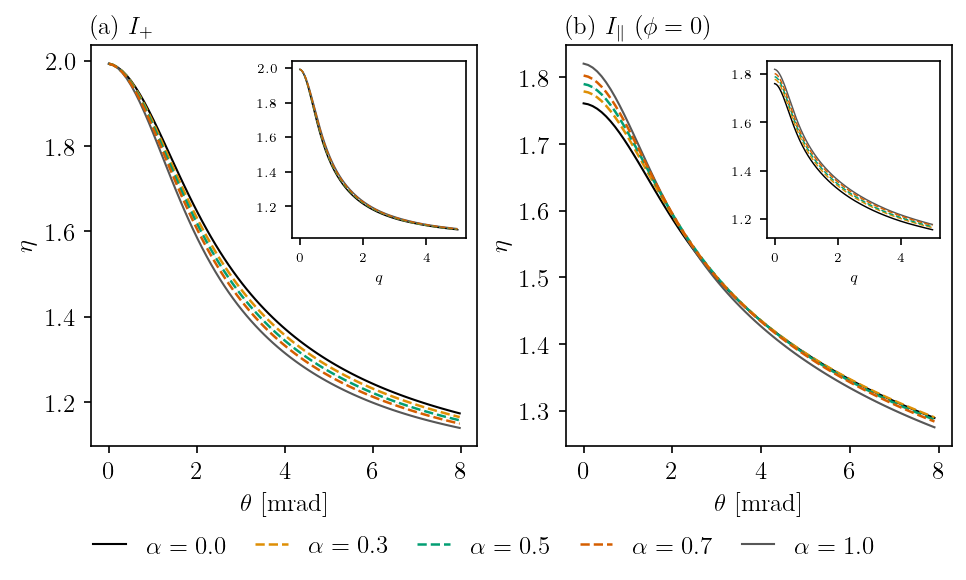

In [15]:
# ===========================================================================
# F10 -- familia gamma(theta; x) + inset de colapso q = k l*(x) theta
# ===========================================================================
F10_X = [0.0, 0.3, 0.5, 0.7, 1.0]
THETA_PLOT_MAX = 8.0     # mrad
Q_INSET_MAX = 5.0


MIN_COLOR = "#000000"
MAX_COLOR = "#575757"

ref_min = 0.0
ref_max = 1.0

apply(width_frac=1.0)
fig, axes = plt.subplots(1, 2, figsize=(TEXTWIDTH_IN, 0.6 * TEXTWIDTH_IN))
for ax, b, ttl in ((axes[0], "circular", r"(a) $I_+$"),
                   (axes[1], "linear",  r"(b) $I_\parallel$ ($\phi=0$)")):
    ch, bs = CHANNELS[b]["main"], BASIS[b]
    axin = ax.inset_axes([0.52, 0.52, 0.45, 0.44])
    for c, x in zip(COL, F10_X):
        i = int(round(x * (len(fraction_list) - 1)))
        g_ = GROUPS[b][i]
        th, q, Em, Sm = profile_stats_theta(SWEEPS[b], g_, PHI_MAIN, ch, basis=bs)
        se = Sm / np.sqrt(len(g_.replicas_keys))
        thm = th * 1e3
        m = thm <= THETA_PLOT_MAX
        mi = q <= Q_INSET_MAX

        if x == ref_min:
            ax.fill_between(thm[m], (Em - se)[m], (Em + se)[m], color=MIN_COLOR, alpha=0.18, lw=0)
            ax.plot(thm[m], Em[m], color=MIN_COLOR, label=rf"$\alpha={x:.1f}$", lw=1)
            axin.plot(q[mi], Em[mi], color=MIN_COLOR, lw=0.7)
        elif x == ref_max:
            ax.fill_between(thm[m], (Em - se)[m], (Em + se)[m], color=MAX_COLOR, alpha=0.18, lw=0)
            ax.plot(thm[m], Em[m], color=MAX_COLOR, label=rf"$\alpha={x:.1f}$", lw=1)
            axin.plot(q[mi], Em[mi], color=MAX_COLOR, lw=0.7)
        else:
            ax.fill_between(thm[m], (Em - se)[m], (Em + se)[m], color=c, alpha=0.18, lw=0)
            ax.plot(thm[m], Em[m], "--", color=c, label=rf"$\alpha={x:.1f}$", zorder=10)
            axin.plot(q[mi], Em[mi], "--", color=c, lw=0.7, zorder=10)

    ax.set_xlabel(r"$\theta$ [mrad]")
    ax.set_ylabel(r"$\eta$")
    ax.grid(False)
    ax.set_title(ttl, loc="left")
    axin.set_xlabel(r"$q$", fontsize=7)
    axin.tick_params(labelsize=6)
    axin.grid(False)

leyenda_inferior(fig, axes[0], ncol=6)
fig.savefig(FIGDIR / "F10_perfil_familia.pdf")
plt.show()


## F11 — Observables vs composición

Panel (a): $\theta_{\rm FWHM}(x)$ por canal, contra dos predicciones del medio efectivo: la **forma** $\propto 1/\ell^*(x)$ anclada en $x=1$ (punteada) y el estimado absoluto de onda plana $0.73/(k\ell^*(x))$ (discontinua; con el haz de 2500 μm, $w/\ell^*\sim10^2$, debería ser cercano). Panel (b): $E(0)(x)$ por canal; sobre lineal-co, la predicción **aditiva sin parámetros libres** construida desde los extremos [Eq. (mix-rho-linear)].


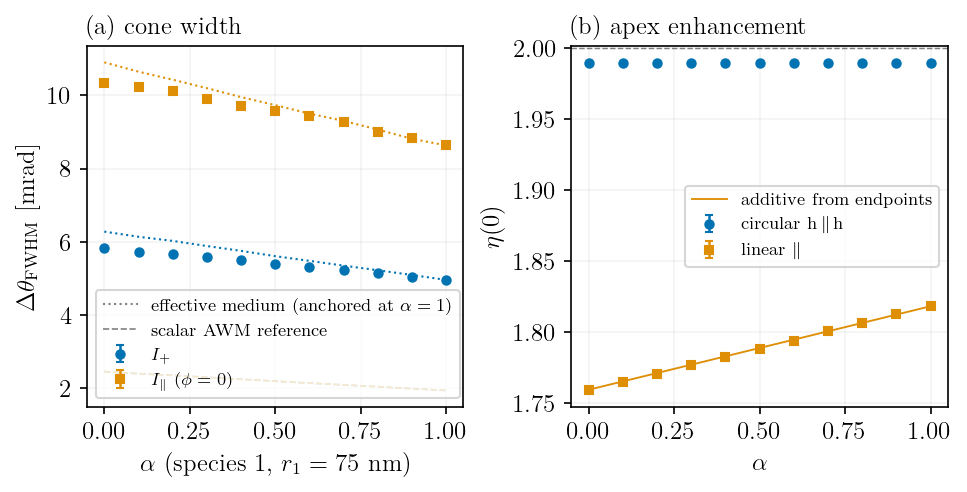

In [16]:
# ===========================================================================
# F11 -- CBS observables vs. composition + effective-medium predictions
# ===========================================================================
C_AWM_SCALAR = 0.73          # scalar AWM lineshape constant (reference only)
ANCHOR       = -1            # index of the anchoring composition (x = 1)

# ---- collect observables -------------------------------------------------
obs = {}
for b in ("circular", "linear"):
    bs = BASIS[b]
    rows = {"main": [], "aux": []}
    for i, g_ in enumerate(GROUPS[b]):
        for key in ("main", "aux"):
            rows[key].append(metric_over_replicas(SWEEPS[b], g_, PHI_MAIN,
                                                  CHANNELS[b][key], bs, LSTAR[b][i]))
    obs[b] = {k: np.array(v) for k, v in rows.items()}   # cols: E0, sE0, fw, sfw

xv = np.asarray(fraction_list)

STYLE = {"circular": dict(color=COL[0], marker="o", label=r"$I_+$"),
         "linear":   dict(color=COL[1], marker="s", label=r"$I_\parallel$ ($\phi=0$)")}

def unpack(b, key="main"):
    """E0, sE0, fw[mrad], sfw[mrad], lstar."""
    E0, sE0, fw, sfw = obs[b][key].T
    return E0, sE0, fw, sfw, np.asarray(LSTAR[b])

def shape_constant(b):
    """C(x) = k l*(x) theta_FWHM(x)  -- dimensionless, FWHM in reduced units."""
    _, _, fw, sfw, ls_ = unpack(b)
    return k * ls_ * fw * 1e-3, k * ls_ * sfw * 1e-3

def anchored_prediction(b):
    """theta_pred(x) = theta(x_anchor) * l*(x_anchor)/l*(x), with anchor error."""
    _, _, fw, sfw, ls_ = unpack(b)
    scale = ls_[ANCHOR] / ls_
    return fw[ANCHOR] * scale, sfw[ANCHOR] * scale

# ---- main figure ---------------------------------------------------------
apply(width_frac=1.0)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(TEXTWIDTH_IN, 0.5 * TEXTWIDTH_IN))

# (a) cone width
for b, st in STYLE.items():
    _, _, fw, sfw, ls_ = unpack(b)
    ax1.errorbar(xv, fw, sfw, fmt=st["marker"], ms=4, capsize=2,
                 color=st["color"], ls="none", label=st["label"])
    pred, _ = anchored_prediction(b)
    ax1.plot(xv, pred, ":", color=st["color"], lw=1.0)
    ax1.plot(xv, C_AWM_SCALAR / (k * ls_) * 1e3, "--", color=st["color"], lw=0.8)

ax1.plot([], [], ":",  c="gray", lw=1.0, label=r"effective medium (anchored at $\alpha=1$)")
ax1.plot([], [], "--", c="gray", lw=0.8, label=r"scalar AWM reference")
ax1.set_xlabel(r"$\alpha$ (species 1, $r_1 = 75$ nm)")
ax1.set_ylabel(r"$\Delta\theta_{\rm FWHM}$ [mrad]")
ax1.grid(alpha=0.15); ax1.legend(fontsize="x-small")
ax1.set_title("(a) cone width", loc="left")

# (b) apex enhancement
for b, lb in (("circular", r"circular h$\,\parallel\,$h"), ("linear", r"linear $\parallel$")):
    E0, sE0, *_ = unpack(b)
    ax2.errorbar(xv, E0, sE0, fmt=STYLE[b]["marker"], ms=4, capsize=2,
                 color=STYLE[b]["color"], ls="none", label=lb)

E0l = obs["linear"]["main"][:, 0]
add = xv * E0l[ANCHOR] + (1 - xv) * E0l[0]
ax2.plot(xv, add, "-", color=COL[1], lw=0.9, label="additive from endpoints")
ax2.axhline(2.0, ls="--", c="gray", lw=0.7)
ax2.set_xlabel(r"$\alpha$")
ax2.set_ylabel(r"$\eta(0)$")
ax2.grid(alpha=0.15); ax2.legend(fontsize="x-small")
ax2.set_title("(b) apex enhancement", loc="left")

fig.savefig(FIGDIR / "F11_observables_vs_x.pdf")
plt.show()

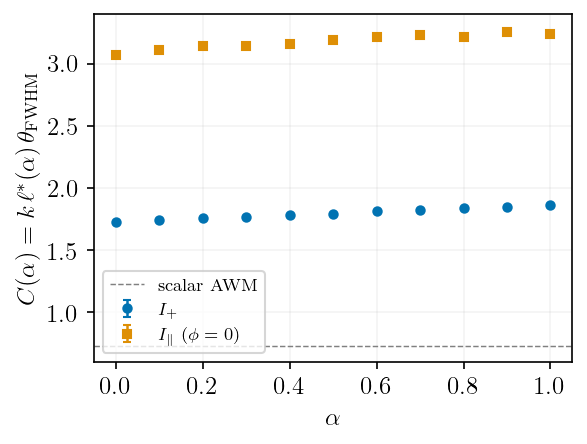

In [17]:
# ===========================================================================
# F11b -- Test 2: lineshape constant C(x) = k l*(x) theta_FWHM(x)
# ===========================================================================
apply(width_frac=0.6)
fig, ax = plt.subplots(figsize=(0.6 * TEXTWIDTH_IN, 0.45 * TEXTWIDTH_IN))
for b, st in STYLE.items():
    C, sC = shape_constant(b)
    ax.errorbar(xv, C, sC, fmt=st["marker"], ms=4, capsize=2,
                color=st["color"], ls="none", label=st["label"])
ax.axhline(C_AWM_SCALAR, ls="--", c="gray", lw=0.7, label="scalar AWM")
ax.set_xlabel(r"$\alpha$")
ax.set_ylabel(r"$C(\alpha) = k\,\ell^*(\alpha)\,\theta_{\rm FWHM}$")
ax.grid(alpha=0.15); ax.legend(fontsize="x-small")
fig.savefig(FIGDIR / "F11b_lineshape_constant.pdf")
plt.show()

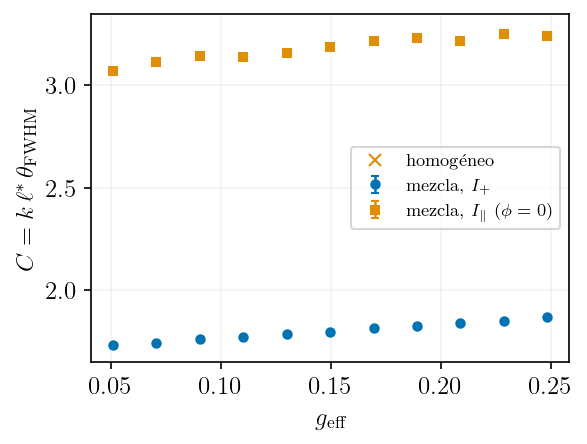

In [18]:
# --- clausura: C_mix(x) cae sobre C_hom(g_eff)? ----------------------------
# g_eff lineal en x por construccion (dq_mix); requiere G1, G2 de la config.
if np.isnan(G1):
    print("[closure] G1/G2 no disponibles: salta la clausura o fijalos a mano")
else:
    g_eff = xv * G1 + (1 - xv) * G2

    # opcional: puntos homogeneos de 5.1 en el mismo canal / mismo corte phi
    C_HOM, G_HOM = {}, None
    try:
        HOM_FOLDERS = {"linear":   "study_homog_timeresolved__PLIN__beam2500",
                       "circular": "study_homog_timeresolved__PCIR__beam2500"}
        HOM_RADII   = [0.020, 0.035, 0.055, 0.075, 0.100]     # excluye R=175
        for b in ("linear", "circular"):
            sw_h = load_sweep(HOM_FOLDERS[b], base_path=Path(save_path))
            Cs, Gs = [], []
            for rad in HOM_RADII:
                keys = sorted(k_ for k_ in sw_h.keys() if f"radius_{rad:.3f}" in k_)
                if not keys:
                    continue
                g_h = Grouped(fraction=np.nan, replicas_keys=keys, name=f"{rad*1e3:.0f} nm")
                ls_h = float(sw_h[keys[0]].params_flat["transport_mean_free_path"])
                _, _, fw_h, _ = metric_over_replicas(sw_h, g_h, PHI_MAIN,
                                                     CHANNELS[b]["main"], BASIS[b], ls_h)
                Cs.append(k * ls_h * fw_h * 1e-3)
                Gs.append(_g_of_run(sw_h, keys[0]))
            C_HOM[b] = np.asarray(Cs)
            G_HOM = np.asarray(Gs)
    except Exception as err:
        print(f"[closure] sin barrido homogeneo: {err}")
        C_HOM = {}

    apply(width_frac=0.6)
    fig, ax = plt.subplots(figsize=(0.6 * TEXTWIDTH_IN, 0.45 * TEXTWIDTH_IN))
    for b, st in STYLE.items():
        C, sC = shape_constant(b)
        ax.errorbar(g_eff, C, sC, fmt=st["marker"], ms=4, capsize=2,
                    color=st["color"], ls="none", label=f"mezcla, {st['label']}")
        if b in C_HOM and G_HOM is not None and len(C_HOM[b]):
            ax.plot(G_HOM, C_HOM[b], "x", ms=6, color=st["color"],
                    label="homogéneo" if b == "linear" else None)
    ax.set_xlabel(r"$g_{\rm eff}$"); ax.set_ylabel(r"$C = k\,\ell^*\,\theta_{\rm FWHM}$")
    ax.grid(alpha=0.15); ax.legend(fontsize="x-small")
    fig.savefig(FIGDIR / "F11c_clausura_C_geff.pdf")
    plt.show()


In [19]:
# --- quotable numbers -----------------------------------------------------
from scipy import stats

for b in ("circular", "linear"):
    _, _, fw, sfw, ls_ = unpack(b)
    pred, spred = anchored_prediction(b)
    mask = np.arange(len(xv)) != (ANCHOR % len(xv))       # anchor defines the curve
    s2 = sfw[mask]**2 + spred[mask]**2
    z  = (fw[mask] - pred[mask]) / np.sqrt(s2)
    chi2, ndf = float(np.sum(z**2)), int(mask.sum())
    print(f"[{b:8s}] Test 1 (anchored): chi2/ndf = {chi2:.2f}/{ndf} = {chi2/ndf:.2f}  "
          f"p = {stats.chi2.sf(chi2, ndf):.3f}   max|z| = {np.abs(z).max():.1f}")

    C, sC = shape_constant(b)
    w = 1.0 / sC**2
    Cbar = np.sum(w * C) / np.sum(w)
    chi2C = float(np.sum(((C - Cbar) / sC)**2)); ndfC = len(C) - 1
    print(f"[{b:8s}] Test 2 (flat C):    C = {Cbar:.3f}   "
          f"chi2/ndf = {chi2C/ndfC:.2f}   drift C(0)/C(1) = {C[0]/C[ANCHOR]:.3f}")

# monotonicity gate
for b in obs:
    d = np.diff(obs[b]["main"][:, 2])
    if not (np.all(d <= 0) or np.all(d >= 0)):
        print(f"[WARN] theta_FWHM(x) non-monotonic in {b}: check extraction/noise")

# apex: additivity of the single-scattering dilution
rho, srho = 2.0 - obs["linear"]["main"][:, 0], obs["linear"]["main"][:, 1]
pred_rho  = xv * rho[ANCHOR] + (1 - xv) * rho[0]
inner     = np.ones(len(xv), bool); inner[[0, ANCHOR]] = False
z_rho     = (rho[inner] - pred_rho[inner]) / srho[inner]
chi2r, ndfr = float(np.sum(z_rho**2)), int(inner.sum())
print(f"[linear  ] additivity of rho: chi2/ndf = {chi2r:.2f}/{ndfr} = {chi2r/ndfr:.2f}  "
      f"p = {stats.chi2.sf(chi2r, ndfr):.3f}")
print(f"rho(0) = {rho[0]:.4f} +/- {srho[0]:.4f}   rho(1) = {rho[ANCHOR]:.4f} +/- {srho[ANCHOR]:.4f}")

fwc = obs["circular"]["main"][:, 2]
lsc = np.asarray(LSTAR["circular"])
print(f"width ratio (circ): FWHM(0)/FWHM(1) = {fwc[0]/fwc[ANCHOR]:.3f}   "
      f"prediction l*(1)/l*(0) = {lsc[ANCHOR]/lsc[0]:.3f}")

[circular] Test 1 (anchored): chi2/ndf = 2391.51/10 = 239.15  p = 0.000   max|z| = 24.6
[circular] Test 2 (flat C):    C = 1.804   chi2/ndf = 174.59   drift C(0)/C(1) = 0.927
[linear  ] Test 1 (anchored): chi2/ndf = 419.35/10 = 41.94  p = 0.000   max|z| = 13.4
[linear  ] Test 2 (flat C):    C = 3.170   chi2/ndf = 77.44   drift C(0)/C(1) = 0.948
[linear  ] additivity of rho: chi2/ndf = 6.30/9 = 0.70  p = 0.709
rho(0) = 0.2407 +/- 0.0005   rho(1) = 0.1818 +/- 0.0003
width ratio (circ): FWHM(0)/FWHM(1) = 1.173   prediction l*(1)/l*(0) = 1.266


## F12 — Test de superposición en $x=0.5$ (Pasos 3–4)

La superposición se construye al nivel de **intensidades** [Eq. (mix-naive)]:
$\eta_{\rm sup} = \dfrac{x\,I_1 + (1-x)\,I_2}{x\,B_1 + (1-x)\,B_2}$,
desde los **acumuladores crudos** de los extremos (no desde formas ajustadas),
**pareando réplica a réplica** — las cinco corridas de extremos se comparten entre
todos los $x$, y el pareo convierte esa correlación en una resta que se cancela
parcialmente, dejando $n$ realizaciones i.i.d. del observable final.

El residual se reporta como $\bar\Delta(\theta) \pm t_{0.975,\,n-1}\,s_\Delta(\theta)/\sqrt{n}$
($t = 2.78$ para $n=5$). El residual esperado es la brecha de Jensen [Eq. (mix-jensen)]:
**nulo en el ápice**, extremal a medio cono, decayendo en las alas — esa estructura
angular distingue el efecto de cualquier artefacto de normalización (que daría un
offset uniforme).


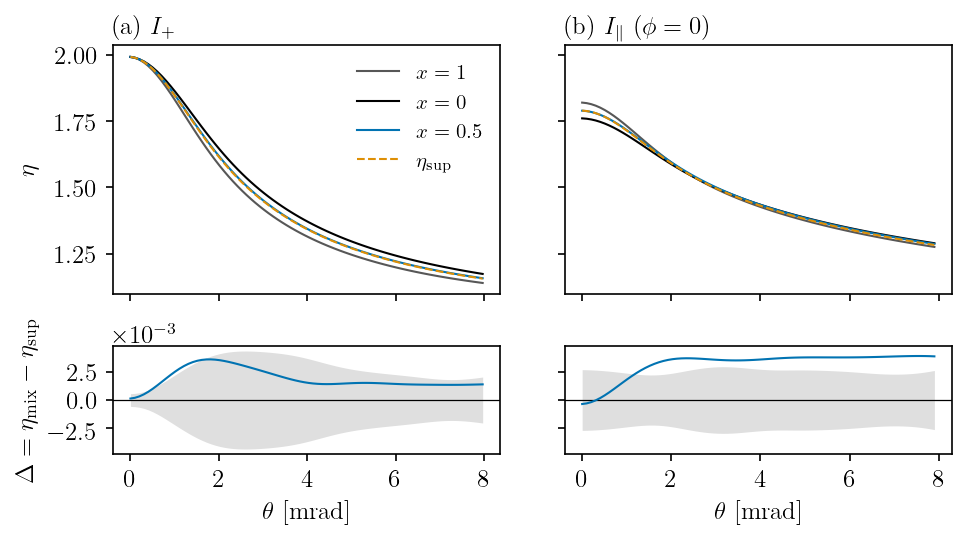

In [20]:
# ===========================================================================
# F12 -- superposicion naive vs mezcla simulada en x = 0.5  (Pasos 3-4)
# ===========================================================================
X_TEST = 0.5
I_TEST = int(round(X_TEST * (len(fraction_list) - 1)))
THETA_PLOT_MAX = 8.0

import matplotlib.ticker as ticker



apply(width_frac=1.0)

# Columna 0: Lineal | Columna 1: Circular
# Fila 0: Perfiles (eta) | Fila 1: Error (Delta)
fig, axes = plt.subplots(
    nrows=2, 
    ncols=2, 
    figsize=(TEXTWIDTH_IN, 0.55 * TEXTWIDTH_IN),
    sharex="col",   # Compartir eje X por columna
    sharey="row",   # Compartir eje Y por fila (crucial para no distorsionar escalas)
    gridspec_kw={"height_ratios": [3, 1.3], "hspace": 0.08, "wspace": 0.12}
)

# Definimos el orden explícito de las columnas (Lineal primero, luego Circular)
BASES = ["circular", "linear"]

for col_idx, b in enumerate(BASES):
    ax_profile = axes[0, col_idx]  # Fila 0: Perfil CBS
    ax_error   = axes[1, col_idx]  # Fila 1: Error/Residual

    # Carga de datos
    ch, bs = CHANNELS[b]["main"], BASIS[b]
    pr = paired_residual(b, I_TEST)
    thm = pr["theta"] * 1e3
    m = thm <= THETA_PLOT_MAX

    _, _, E0m, _ = profile_stats_theta(SWEEPS[b], GROUPS[b][0],  PHI_MAIN, ch, basis=bs)
    _, _, E1m, _ = profile_stats_theta(SWEEPS[b], GROUPS[b][-1], PHI_MAIN, ch, basis=bs)

    # -----------------------------------------------------------------------
    # FILA 1: PERFIL CBS (\eta)
    # -----------------------------------------------------------------------
    ax_profile.plot(thm[m], E1m[m], color=MAX_COLOR, lw=1, label=r"$x=1$")
    ax_profile.plot(thm[m], E0m[m], color=MIN_COLOR, lw=1, label=r"$x=0$")
    ax_profile.plot(thm[m], pr["sim_mean"][m], color=COL[0], lw=1, label=r"$x=0.5$")
    ax_profile.plot(thm[m], pr["naive_mean"][m], "--", color=COL[1], lw=1, label=r"$\eta_{\rm sup}$")
    ax_profile.grid(False)

    # Título de columna (opcional pero ayuda a identificar cada base)
    ax_profile.set_title(r"(b) $I_\parallel$ ($\phi=0$)" if b == "linear" else r"(a) $I_+$", loc="left")

    # Solo agregamos la leyenda en la primera columna para no duplicar
    if col_idx == 0:
        ax_profile.set_ylabel(r"$\eta$")
        ax_profile.legend(frameon=False, fontsize="small")

    # -----------------------------------------------------------------------
    # FILA 2: ERROR / RESIDUAL (\Delta)
    # -----------------------------------------------------------------------
    band = pr["res_ci"]
    ax_error.axhline(0, c="k", lw=0.6)
    ax_error.fill_between(
        thm[m], -band[m], band[m], 
        color="gray", alpha=0.25, lw=0, 
        label=rf"$\pm t_{{0.975,{pr['n']-1}}}\,$SE"
    )
    ax_error.plot(thm[m], pr["res_mean"][m], color=COL[0], lw=1.0)
    ax_error.set_xlabel(r"$\theta$ [mrad]")
    ax_error.grid(False)

    # Solo la primera columna lleva etiqueta en el eje Y
    if col_idx == 0:
        ax_error.set_ylabel(r"$\Delta = \eta_{\rm mix}-\eta_{\rm sup}$")

# Aplicar a la fila de los residuales (fila 1)
axes[1, 0].yaxis.set_major_formatter(ticker.ScalarFormatter(useMathText=True))
axes[1, 0].ticklabel_format(style="sci", axis="y", scilimits=(0,0))

# Ajuste fino final de diseño
fig.align_ylabels(axes[:, 0])
fig.savefig(FIGDIR / "F12_superposicion.pdf", bbox_inches="tight")
plt.show()


## F13 — Familia $\bar\Delta(\theta;x)$ (Paso 4)

La verificación cualitativa de la predicción **(iii)** se hace aquí, a ojo y con banda
de confianza: para cada composición interior, $\bar\Delta(\theta)$ con su IC t-Student.
Debe **anularse en el ápice** (en $\theta=0$, $F(0)=2$ para cualquier argumento, y la
dilución por dispersión simple, al ser aditiva, también coincide), alcanzar un extremo
a $q$ intermedio (donde domina la curvatura de $F$) y decaer en las alas. La amplitud
debe crecer hacia $x=0.5$ (predicción **(i)**, cuantificada en F12b).


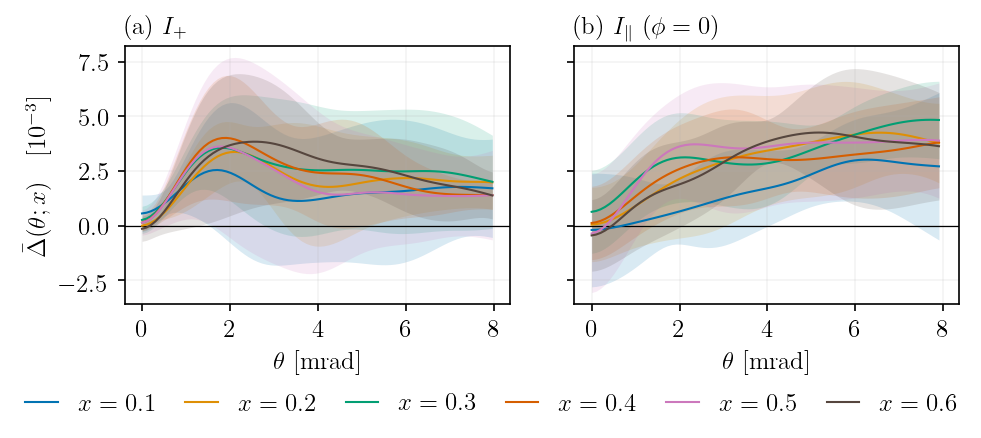

chequeo Delta(0) = 0 (|z| < 2 => compatible):


,base,x,z_apex
0,circular,0.1,2.08
1,circular,0.2,0.79
2,circular,0.3,1.51
3,circular,0.4,1.56
4,circular,0.5,1.00
5,circular,0.6,-0.32
6,linear,0.1,-0.20
7,linear,0.2,0.12
8,linear,0.3,1.00
9,linear,0.4,0.27


[WARN] Delta(0) incompatible con 0 en alguna composicion: revisar deposito de dispersion simple en ambos acumuladores (trampa 3)


In [21]:
# ===========================================================================
# F13 -- familia Delta(theta; x) con IC t-Student + chequeo del apice
# ===========================================================================
THETA_PLOT_MAX = 8.0
apex_rows = []

apply(width_frac=1.0)

# 1 Fila, 2 Columnas (Circular / Lineal)
fig, axes = plt.subplots(
    nrows=1, 
    ncols=2, 
    figsize=(TEXTWIDTH_IN, 0.45 * TEXTWIDTH_IN),
    sharex=True,
    sharey=True,
    gridspec_kw={"wspace": 0.12}
)

BASES = ["circular", "linear"]

for col_idx, b in enumerate(BASES):
    ax = axes[col_idx]
    ax.axhline(0, c="k", lw=0.6)

    # Iterar sobre las fracciones intermedias
    for c, i in zip(COL, range(1, len(fraction_list) - 1)):
        pr = paired_residual(b, i)
        thm = pr["theta"] * 1e3
        m = thm <= THETA_PLOT_MAX

        # Trazo de líneas e intervalos de confianza
        ax.plot(
            thm[m], pr["res_mean"][m], color=c, lw=1.0,
            label=rf"$x={pr['x']:.1f}$"
        )
        ax.fill_between(
            thm[m], 
            (pr["res_mean"] - pr["res_ci"])[m],
            (pr["res_mean"] + pr["res_ci"])[m],
            color=c, alpha=0.15, lw=0
        )

        # Chequeo del ápice
        n_ap = 3
        z_ap = np.mean(pr["res_mean"][:n_ap]) / (np.mean(pr["res_se"][:n_ap]) + 1e-30)
        apex_rows.append({"base": b, "x": pr["x"], "z_apex": z_ap})

    # Formato de ejes y títulos por columna
    ax.set_xlabel(r"$\theta$ [mrad]")
    ax.grid(alpha=0.15)
    ax.set_title(r"(a) $I_+$" if b == "circular" else r"(b) $I_\parallel$ ($\phi=0$)", loc="left")

    # Etiqueta Y solo en la primera columna
    if col_idx == 0:
        ax.set_ylabel(r"$\bar\Delta(\theta;x)$")
axes[0].set_ylabel(r"$\bar\Delta(\theta;x) \quad [10^{-3}]$")
axes[0].yaxis.get_offset_text().set_visible(False)
# Notación científica limpia en el eje Y (compartido)
axes[0].yaxis.set_major_formatter(ticker.ScalarFormatter(useMathText=True))
axes[0].ticklabel_format(style="sci", axis="y", scilimits=(0,0))

# Leyenda unificada para toda la figura
leyenda_inferior(fig, axes[0], ncol=6)

# Alineación y guardado
fig.align_ylabels(axes)
fig.savefig(FIGDIR / "F13_delta_familia.pdf", bbox_inches="tight")
plt.show()

# ---------------------------------------------------------------------------
# Verificación de datos del Ápice
# ---------------------------------------------------------------------------
df_apex = pd.DataFrame(apex_rows)
print("chequeo Delta(0) = 0 (|z| < 2 => compatible):")
display(df_apex.round(2))
if (df_apex["z_apex"].abs() > 2).any():
    print("[WARN] Delta(0) incompatible con 0 en alguna composicion: "
          "revisar deposito de dispersion simple en ambos acumuladores (trampa 3)")
    

## F12b — Escalado $x(1-x)$ y escalares del residual (Paso 5)

Predicción **(i)** de la expansión de Jensen: la amplitud del residual es
$\propto x(1-x)$. Sobre la ventana angular fija se extraen, **por réplica**, el RMS,
el extremo con signo $\Delta_{\rm ext}$ y su posición $q_{\rm ext}$; se reportan como
media $\pm\,t_{0.975,n-1}\,{\rm SE}$.

Para el ajuste ${\rm RMS}(x) = A\,x(1-x)$ (recta por el origen, ponderada) se usa la
**señal** del perfil medio — RMS con el **piso de ruido** (RMS esperado si el residual
fuera cero, estimado del SE por réplicas) restado en cuadratura — porque el RMS por
réplica está sesgado hacia arriba por su propio ruido. El estadístico de bondad de
ajuste ($\chi^2$/dof) es el número que se reporta. El signo de $\Delta_{\rm ext}$ y la
estabilidad de $q_{\rm ext}$ en $x$ se contrastan con la predicción de curvatura (F14).


[circular] x=0.1   RMS(medio)=1.68e-03   piso=1.03e-03   señal=1.34e-03   Δ_ext=+3.06e-03±3.94e-03   q_ext=1.28±0.79
[circular] x=0.2   RMS(medio)=2.34e-03   piso=6.93e-04   señal=2.23e-03   Δ_ext=+3.88e-03±8.61e-04   q_ext=0.78±0.34
[circular] x=0.3   RMS(medio)=2.73e-03   piso=9.12e-04   señal=2.58e-03   Δ_ext=+3.98e-03±2.29e-03   q_ext=0.77±0.49
[circular] x=0.4   RMS(medio)=2.82e-03   piso=7.92e-04   señal=2.71e-03   Δ_ext=+4.24e-03±2.52e-03   q_ext=1.05±0.78
[circular] x=0.5   RMS(medio)=2.35e-03   piso=1.21e-03   señal=2.01e-03   Δ_ext=+3.57e-03±4.13e-03   q_ext=0.70±0.30
[circular] x=0.6   RMS(medio)=3.02e-03   piso=8.03e-04   señal=2.91e-03   Δ_ext=+4.32e-03±2.90e-03   q_ext=0.98±0.58
[circular] x=0.7   RMS(medio)=1.64e-03   piso=9.49e-04   señal=1.34e-03   Δ_ext=+2.55e-03±3.73e-03   q_ext=1.33±0.92
[circular] x=0.8   RMS(medio)=1.39e-03   piso=7.53e-04   señal=1.17e-03   Δ_ext=+2.77e-03±2.50e-03   q_ext=1.26±0.87
[circular] x=0.9   RMS(medio)=7.60e-04   piso=1.15e-03   señal=0

/var/folders/hl/qm9fczw178qg19fkz2_x7sqr0000gn/T/ipykernel_1873/1769150208.py:54: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


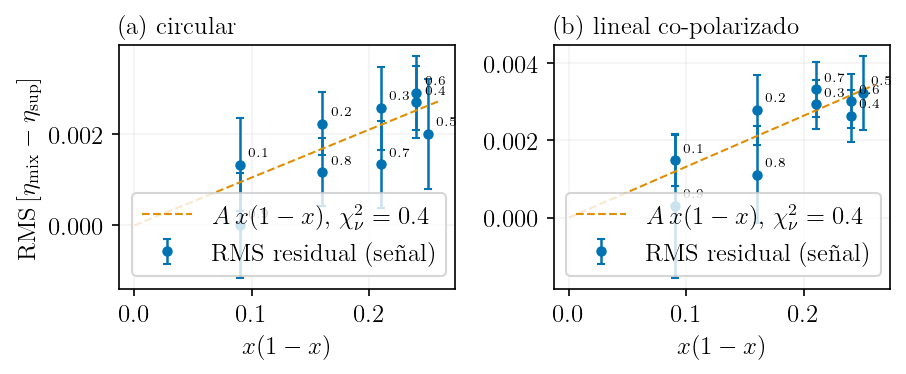

/var/folders/hl/qm9fczw178qg19fkz2_x7sqr0000gn/T/ipykernel_1873/1769150208.py:72: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


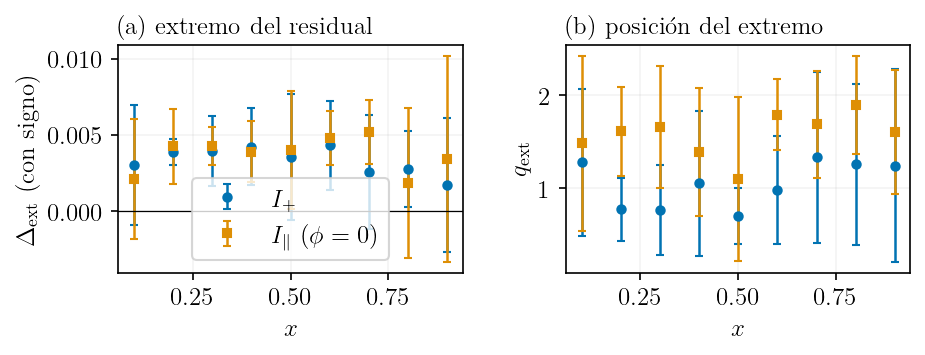

In [22]:
# ===========================================================================
# F12b -- RMS(x) = A x(1-x) + escalares por replica (Delta_ext, q_ext)
# ===========================================================================
W_MRAD = CONV["w_mrad_residual"]

scal = {}          # base -> lista de dicts por composicion interior
apply(width_frac=1.0)
fig, axes = plt.subplots(1, 2, figsize=(TEXTWIDTH_IN, 0.42 * TEXTWIDTH_IN), sharex=True)
for ax, b, ttl in ((axes[0], "circular", "(a) circular"),
                   (axes[1], "linear", "(b) lineal co-polarizado")):
    rows = []
    for i in range(1, len(fraction_list) - 1):
        pr = paired_residual(b, i)
        sc = residual_scalars(pr, w_mrad=W_MRAD)
        n = pr["n"]; tc = pr["tcrit"]
        rows.append({
            "x": pr["x"],
            "rms_signal": sc["signal"], "floor": sc["floor"],
            "rms_rep_mean": sc["rms_reps"].mean(),
            "rms_rep_ci":   tc * sc["rms_reps"].std(ddof=1) / np.sqrt(n),
            "ext_mean":     sc["ext_reps"].mean(),
            "ext_ci":       tc * sc["ext_reps"].std(ddof=1) / np.sqrt(n),
            "qext_mean":    sc["qext_reps"].mean(),
            "qext_ci":      tc * sc["qext_reps"].std(ddof=1) / np.sqrt(n),
        })
        print(f"[{b}] x={pr['x']:.1f}   RMS(medio)={sc['rms_mean']:.2e}   "
              f"piso={sc['floor']:.2e}   señal={sc['signal']:.2e}   "
              f"Δ_ext={rows[-1]['ext_mean']:+.2e}±{rows[-1]['ext_ci']:.2e}   "
              f"q_ext={rows[-1]['qext_mean']:.2f}±{rows[-1]['qext_ci']:.2f}")
    scal[b] = pd.DataFrame(rows)

    d = scal[b]
    u = d["x"].values * (1 - d["x"].values)
    amp, s_amp = d["rms_signal"].values, d["floor"].values

    w = 1.0 / np.maximum(s_amp, 1e-12) ** 2                  # recta por el origen
    slope = np.sum(w * u * amp) / np.sum(w * u ** 2)
    resid = amp - slope * u
    chi2fit = np.sum(w * resid ** 2) / max(len(u) - 1, 1)
    uu = np.linspace(0, 0.26, 50)

    ax.errorbar(u, amp, s_amp, fmt="o", ms=4, capsize=2, color=COL[0], ls="none",
                label="RMS residual (señal)")
    ax.plot(uu, slope * uu, "--", color=COL[1], lw=1.0,
            label=rf"$A\,x(1-x)$, $\chi^2_\nu={chi2fit:.1f}$")
    for xi, ui, ai in zip(d["x"], u, amp):
        ax.annotate(rf"${xi:.1f}$", (ui, ai), textcoords="offset points",
                    xytext=(4, 4), fontsize=6.5)
    ax.set_xlabel(r"$x(1-x)$")
    ax.set_title(ttl, loc="left")
    ax.grid(alpha=0.15); ax.legend()
    print(f"[{b}] ajuste RMS = A x(1-x):  A = {slope:.2e}   chi2/dof = {chi2fit:.2f}")
axes[0].set_ylabel(r"RMS$\,[\eta_{\rm mix}-\eta_{\rm sup}]$")
fig.tight_layout()
fig.savefig(FIGDIR / "F12b_escalado_x1mx.pdf")
plt.show()

# --- panel complementario: Delta_ext(x) con signo y q_ext(x) ----------------
apply(width_frac=1.0)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(TEXTWIDTH_IN, 0.4 * TEXTWIDTH_IN))
for b, st in STYLE.items():
    d = scal[b]
    ax1.errorbar(d["x"], d["ext_mean"], d["ext_ci"], fmt=st["marker"], ms=4,
                 capsize=2, color=st["color"], ls="none", label=st["label"])
    ax2.errorbar(d["x"], d["qext_mean"], d["qext_ci"], fmt=st["marker"], ms=4,
                 capsize=2, color=st["color"], ls="none", label=st["label"])
ax1.axhline(0, c="k", lw=0.6)
ax1.set_xlabel(r"$x$"); ax1.set_ylabel(r"$\Delta_{\rm ext}$ (con signo)")
ax1.set_title("(a) extremo del residual", loc="left"); ax1.grid(alpha=0.15); ax1.legend()
ax2.set_xlabel(r"$x$"); ax2.set_ylabel(r"$q_{\rm ext}$")
ax2.set_title("(b) posición del extremo", loc="left"); ax2.grid(alpha=0.15)
fig.tight_layout()
fig.savefig(FIGDIR / "F12b_ext_qext.pdf")
plt.show()


## F14 — Predicción de curvatura: brecha de Jensen sobre la forma AWM (Sección 2)

Modelo por especie: $F(\theta;s) = 1 + A(s)\,\mathcal{C}\!\big(W\,k\theta/s\big)$, con
$\mathcal{C}$ el cono difusivo de Akkermans ($b = 0.7104$), $A$ interpolada linealmente
entre las amplitudes medidas de los extremos (la dilución $\rho$ es aditiva) y $W$ un
factor de anchura calibrado **una sola vez** en $x=1$ (el cono medido es más ancho que
el difusivo puro; misma $\beta$ de §5.1 vista desde aquí).

La brecha del modelo es la de Jensen **exacta** (sin truncar):
$$\Delta_{\rm pred}(\theta;x) = F(\theta;s_{\rm eff}) - \big[x\,F(\theta;s_1) + (1-x)\,F(\theta;s_2)\big],$$
y su versión a 2º orden $-\tfrac12 x(1-x)(s_1-s_2)^2\,\partial_s^2 F$ da el **signo** y
$q_{\rm ext}$ predichos. No hay parámetros ajustados a $\Delta$ medido: la comparación
es absoluta.


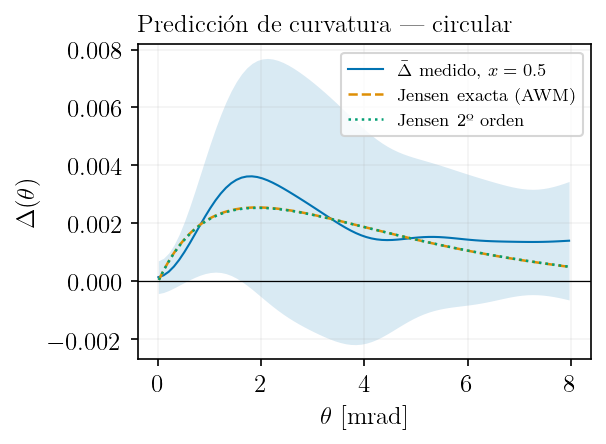

[F14 circular] W = 0.352   s1 = 0.0433, s2 = 0.0547 [1/um]   s_eff(0.5) = 0.0490
[F14 circular] prediccion: signo(Δ_ext) = +1, Δ_ext = +2.55e-03, q_ext = 0.63
[F14 circular] medido:     signo(Δ_ext) = +1, Δ_ext = +3.57e-03, q_ext = 0.70


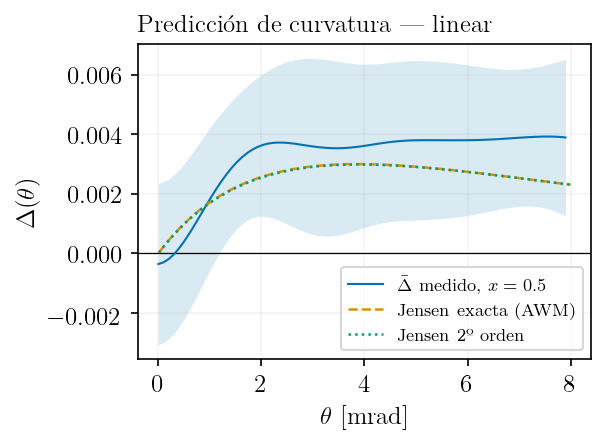

[F14 linear] W = 0.203   s1 = 0.0433, s2 = 0.0547 [1/um]   s_eff(0.5) = 0.0490
[F14 linear] prediccion: signo(Δ_ext) = +1, Δ_ext = +3.00e-03, q_ext = 1.28
[F14 linear] medido:     signo(Δ_ext) = +1, Δ_ext = +4.01e-03, q_ext = 1.10


In [23]:
# ===========================================================================
# F14 -- prediccion de curvatura (Jensen sobre la forma AWM) vs Delta medido
# ===========================================================================
THETA_GRID = np.linspace(1e-5, 8.0e-3, 400)      # rad

def calibrate_W(b):
    """Factor de anchura W: FWHM del modelo == FWHM medido en x=1 (en q)."""
    _, _, fw, _, ls_ = unpack(b)
    C_meas = k * ls_[-1] * fw[-1] * 1e-3         # FWHM medido en q, x=1
    # FWHM del cono unidad: 2*u_half con C(u_half) = 1/2
    from scipy.optimize import brentq
    u_half = brentq(lambda u: cone_shape(u) - 0.5, 1e-6, 50.0)
    return 2.0 * u_half / C_meas

def F_model(theta, s, A, W):
    return 1.0 + A * cone_shape(W * k * theta / s)

for b in ("circular", "linear"):
    E0, sE0, *_ = unpack(b)
    A1, A2 = E0[-1] - 1.0, E0[0] - 1.0           # amplitudes medidas de los extremos
    W = calibrate_W(b)
    s1, s2 = S1, S2

    def A_of_s(s):                               # A lineal en s (rho aditiva)
        return A2 + (A1 - A2) * (s - s2) / (s1 - s2)

    apply(width_frac=0.62)
    fig, ax = plt.subplots(figsize=(0.62 * TEXTWIDTH_IN, 0.45 * TEXTWIDTH_IN))
    ax.axhline(0, c="k", lw=0.6)

    pr = paired_residual(b, I_TEST)              # x = 0.5, medido
    thm = pr["theta"] * 1e3
    m = thm <= 8.0
    ax.plot(thm[m], pr["res_mean"][m], color=COL[0], lw=1.0,
            label=rf"$\bar\Delta$ medido, $x={pr['x']:.1f}$")
    ax.fill_between(thm[m], (pr["res_mean"] - pr["res_ci"])[m],
                    (pr["res_mean"] + pr["res_ci"])[m], color=COL[0], alpha=0.15, lw=0)

    x = pr["x"]
    s_eff = x * s1 + (1 - x) * s2
    D_exact = (F_model(THETA_GRID, s_eff, A_of_s(s_eff), W)
               - (x * F_model(THETA_GRID, s1, A1, W)
                  + (1 - x) * F_model(THETA_GRID, s2, A2, W)))
    # 2o orden: -1/2 x(1-x) (s1-s2)^2 d2F/ds2 |_{s_eff}  (diferencia central)
    ds = 1e-3 * s_eff
    d2F = (F_model(THETA_GRID, s_eff + ds, A_of_s(s_eff + ds), W)
           - 2 * F_model(THETA_GRID, s_eff, A_of_s(s_eff), W)
           + F_model(THETA_GRID, s_eff - ds, A_of_s(s_eff - ds), W)) / ds**2
    D_2nd = -0.5 * x * (1 - x) * (s1 - s2) ** 2 * d2F

    thg = THETA_GRID * 1e3
    ax.plot(thg, D_exact, "--", color=COL[1], lw=1.2, label="Jensen exacta (AWM)")
    ax.plot(thg, D_2nd, ":", color=COL[2], lw=1.2, label="Jensen 2º orden")
    ax.set_xlabel(r"$\theta$ [mrad]"); ax.set_ylabel(r"$\Delta(\theta)$")
    ax.set_title(f"Predicción de curvatura — {b}", loc="left")
    ax.grid(alpha=0.15); ax.legend(fontsize="x-small")
    fig.savefig(FIGDIR / f"F14_jensen_pred_{b}.pdf")
    plt.show()

    # numeros citables: signo y posicion del extremo predicho vs medido
    j = int(np.argmax(np.abs(D_exact)))
    q_ext_pred = k * (1.0 / s_eff) * THETA_GRID[j]
    sc = residual_scalars(pr)
    print(f"[F14 {b}] W = {W:.3f}   s1 = {s1:.4f}, s2 = {s2:.4f} [1/um]   "
          f"s_eff(0.5) = {s_eff:.4f}")
    print(f"[F14 {b}] prediccion: signo(Δ_ext) = {np.sign(D_exact[j]):+.0f}, "
          f"Δ_ext = {D_exact[j]:+.2e}, q_ext = {q_ext_pred:.2f}")
    print(f"[F14 {b}] medido:     signo(Δ_ext) = {np.sign(sc['ext_reps'].mean()):+.0f}, "
          f"Δ_ext = {sc['ext_reps'].mean():+.2e}, q_ext = {sc['qext_reps'].mean():.2f}")


## Paso 6 — Las aditividades que sí se cumplen

La brecha de Jensen es la **no**-aditividad; el capítulo necesita también las
aditividades que sí se cumplen, medidas en el mismo pipeline:

1. **Anchura:** $\theta_{\rm FWHM}(x) = C/(k\,\ell^*_{\rm eff}(x))$ y $1/\ell^*_{\rm eff}$ es
   lineal en $x$ ⇒ a constante de forma fija, ${\rm FWHM}$ en $\theta$ físico es
   **lineal en $x$**. Las desviaciones de linealidad *son* la deriva $C(g_{\rm eff})$ del
   ~7 %: el mismo efecto tensorial de canal visto desde otro ángulo, no un fallo.
2. **Colapso en $q$:** todos los $\eta_{\rm mix}(x)$ contra $q = k\,\ell^*_{\rm eff}(x)\,\theta$.
   El colapso valida el medio efectivo; los residuos del colapso son, de nuevo,
   información de forma.
3. **Dilución simple:** $\rho(x) = x\rho_1 + (1-x)\rho_2$ (rompe la degeneración de $\ell^*$) — ya en "quotable numbers".
4. **Control de reciprocidad:** $\eta(0)$ en $h\parallel h$ constante en $x$ ($\approx 1.99$).

La narrativa resultante: aditivo a nivel de coeficientes y de dispersión simple,
no aditivo a nivel de perfil, con desviación de segundo orden predicha y verificada.


[paso6 circular] FWHM lineal en x: chi2/dof = 1.31   desviacion max = 0.3 %  (= deriva C(g_eff))
[paso6 linear] FWHM lineal en x: chi2/dof = 4.51   desviacion max = 0.9 %  (= deriva C(g_eff))
[paso6 linear] residuo RMS del colapso: max sobre x = 2.02e-02  (apices separados por rho(x): informacion de forma, no fallo)
[paso6 circular] reciprocidad: eta(0) = 1.9896   chi2/dof = 1.54   (esperado ~1.99, constante en x)


/var/folders/hl/qm9fczw178qg19fkz2_x7sqr0000gn/T/ipykernel_1873/1092188816.py:53: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


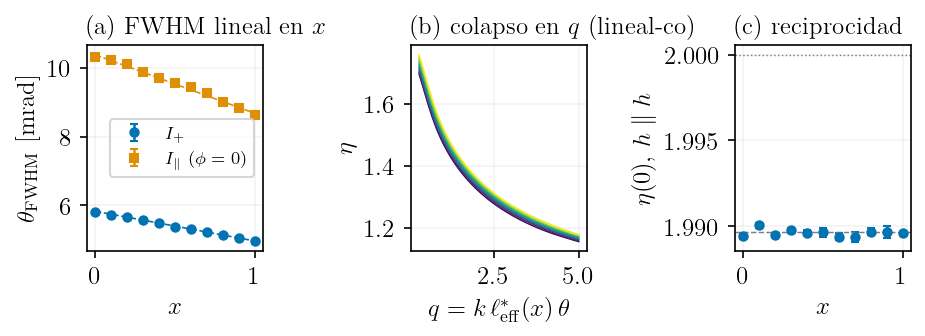

In [24]:
# ===========================================================================
# Paso 6 -- tests complementarios de aditividad
# ===========================================================================
apply(width_frac=1.0)
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(TEXTWIDTH_IN, 0.38 * TEXTWIDTH_IN))

# ---------- (1) FWHM(theta) lineal en x ------------------------------------
for b, st in STYLE.items():
    _, _, fw, sfw, _ = unpack(b)
    ax1.errorbar(xv, fw, sfw, fmt=st["marker"], ms=4, capsize=2,
                 color=st["color"], ls="none", label=st["label"])
    w = 1.0 / sfw**2
    (b1, b0), cov = np.polyfit(xv, fw, 1, w=np.sqrt(w), cov=True)
    chi2 = np.sum(w * (fw - (b1 * xv + b0))**2) / (len(xv) - 2)
    ax1.plot(xv, b1 * xv + b0, "--", color=st["color"], lw=0.8)
    resmax = np.max(np.abs(fw - (b1 * xv + b0)) / (b1 * xv + b0))
    print(f"[paso6 {b}] FWHM lineal en x: chi2/dof = {chi2:.2f}   "
          f"desviacion max = {100*resmax:.1f} %  (= deriva C(g_eff))")
ax1.set_xlabel(r"$x$"); ax1.set_ylabel(r"$\theta_{\rm FWHM}$ [mrad]")
ax1.set_title("(a) FWHM lineal en $x$", loc="left")
ax1.grid(alpha=0.15); ax1.legend(fontsize="x-small")

# ---------- (2) colapso en q y sus residuos --------------------------------
b = "linear"; ch, bs = CHANNELS[b]["main"], BASIS[b]
QG = np.linspace(0.3, 5.0, 140)
curvas = []
for c, g_ in zip(plt.cm.viridis(np.linspace(0, 1, len(GROUPS[b]))), GROUPS[b]):
    _, q, Em, _ = profile_stats_theta(SWEEPS[b], g_, PHI_MAIN, ch, basis=bs)
    Ei = np.interp(QG, q, Em)
    curvas.append(Ei)
    ax2.plot(QG, Ei, lw=0.7, color=c)
curvas = np.vstack(curvas)
ref = curvas.mean(axis=0)
rms_colapso = np.sqrt(np.mean((curvas - ref) ** 2, axis=1))
ax2.set_xlabel(r"$q = k\,\ell^*_{\rm eff}(x)\,\theta$"); ax2.set_ylabel(r"$\eta$")
ax2.set_title("(b) colapso en $q$ (lineal-co)", loc="left"); ax2.grid(alpha=0.15)
print(f"[paso6 linear] residuo RMS del colapso: max sobre x = {rms_colapso.max():.2e}  "
      f"(apices separados por rho(x): informacion de forma, no fallo)")

# ---------- (4) reciprocidad: eta(0) en h||h constante en x ----------------
E0c, sE0c, *_ = unpack("circular")
ax3.errorbar(xv, E0c, sE0c, fmt="o", ms=4, capsize=2, color=COL[0], ls="none")
w = 1.0 / sE0c**2
E0bar = np.sum(w * E0c) / np.sum(w)
chi2E = np.sum(w * (E0c - E0bar)**2) / (len(E0c) - 1)
ax3.axhline(E0bar, ls="--", c="gray", lw=0.7)
ax3.axhline(2.0, ls=":", c="gray", lw=0.7)
ax3.set_xlabel(r"$x$"); ax3.set_ylabel(r"$\eta(0)$, $h\parallel h$")
ax3.set_title("(c) reciprocidad", loc="left"); ax3.grid(alpha=0.15)
print(f"[paso6 circular] reciprocidad: eta(0) = {E0bar:.4f}   chi2/dof = {chi2E:.2f}   "
      f"(esperado ~1.99, constante en x)")

fig.tight_layout()
fig.savefig(FIGDIR / "F15_paso6.pdf")
plt.show()


## Tabla de degeneración

$(x,\ \ell^*,\ \theta_{\rm FWHM},\ E_0^{\rm circ},\ E_0^{\rm lin,co},\ \rho)$ con errores
estándar sobre réplicas. Exporta CSV (datos) y filas LaTeX listas para
`tab:mix-degeneracy`. El punto de la sección: el ancho mide solo $\ell^*(x)$ (degenerado
con un monodisperso equivalente); $\rho(x)$ discrimina composición.


In [25]:
# ===========================================================================
# Tabla de degeneración -> CSV + filas LaTeX
#   Requiere haber corrido F11 (usa `obs`).
# ===========================================================================
rows = []
for i, x in enumerate(fraction_list):
    E0c, sE0c, fwc, sfwc = obs["circular"]["main"][i]
    E0l, sE0l, fwl, sfwl = obs["linear"]["main"][i]
    rows.append({
        "x": x, "lstar_um": LSTAR["circular"][i],
        "FWHM_circ_mrad": fwc, "s_FWHM_circ": sfwc,
        "FWHM_lin_mrad": fwl, "s_FWHM_lin": sfwl,
        "E0_circ": E0c, "s_E0_circ": sE0c,
        "E0_lin_co": E0l, "s_E0_lin": sE0l,
        "rho": 2.0 - E0l, "s_rho": sE0l,
    })
df_deg = pd.DataFrame(rows)
df_deg.to_csv(FIGDIR / "tabla_degeneracion.csv", index=False)
display(df_deg.round(4))

def pm(v, s, nd=3):
    return rf"${v:.{nd}f} \pm {s:.{nd}f}$"

lines = []
for _, r in df_deg.iterrows():
    lines.append("    " + " & ".join([
        f"{r['x']:.1f}",
        f"{r['lstar_um']:.2f}",
        pm(r["FWHM_circ_mrad"], r["s_FWHM_circ"], 2),
        pm(r["E0_circ"], r["s_E0_circ"]),
        pm(r["E0_lin_co"], r["s_E0_lin"]),
        pm(r["rho"], r["s_rho"]),
    ]) + r" \\")
tex = "\n".join(lines)
(FIGDIR / "tabla_degeneracion.tex").write_text(tex)
print(tex)

span_fw = 100 * (df_deg["FWHM_circ_mrad"].iloc[0] / df_deg["FWHM_circ_mrad"].iloc[-1] - 1)
span_rho = 100 * (df_deg["rho"].iloc[0] / df_deg["rho"].iloc[-1] - 1)
print(f"\ncontraste a través del barrido:  FWHM_circ {span_fw:.0f} %    rho {span_rho:.0f} %")
print(f"guardado: {FIGDIR/'tabla_degeneracion.csv'} y {FIGDIR/'tabla_degeneracion.tex'}")


,x,lstar_um,FWHM_circ_mrad,s_FWHM_circ,FWHM_lin_mrad,s_FWHM_lin,E0_circ,s_E0_circ,E0_lin_co,s_E0_lin,rho,s_rho
0,0.0,18.2956,5.8162,0.0115,10.3274,0.0176,1.9894,0.0002,1.7593,0.0005,0.2407,0.0005
1,0.1,18.7145,5.7235,0.0120,10.2290,0.0213,1.9900,0.0001,1.7649,0.0004,0.2351,0.0004
2,0.2,19.0641,5.6759,0.0104,10.1115,0.0306,1.9895,0.0001,1.7708,0.0003,0.2292,0.0003
3,0.3,19.5195,5.5742,0.0127,9.8849,0.0223,1.9898,0.0002,1.7771,0.0004,0.2229,0.0004
4,0.4,19.9658,5.4913,0.0082,9.6967,0.0266,1.9896,0.0002,1.7825,0.0005,0.2175,0.0005
5,0.5,20.4840,5.3845,0.0144,9.5739,0.0168,1.9896,0.0003,1.7880,0.0009,0.2120,0.0009
6,0.6,20.9601,5.3185,0.0078,9.4374,0.0293,1.9894,0.0002,1.7940,0.0005,0.2060,0.0005
7,0.7,21.4741,5.2208,0.0038,9.2739,0.0352,1.9894,0.0003,1.8007,0.0003,0.1993,0.0003
8,0.8,21.9889,5.1407,0.0077,9.0032,0.0098,1.9897,0.0002,1.8064,0.0006,0.1936,0.0006
9,0.9,22.5503,5.0434,0.0139,8.8414,0.0542,1.9896,0.0003,1.8129,0.0006,0.1871,0.0006


    0.0 & 18.30 & $5.82 \pm 0.01$ & $1.989 \pm 0.000$ & $1.759 \pm 0.001$ & $0.241 \pm 0.001$ \\
    0.1 & 18.71 & $5.72 \pm 0.01$ & $1.990 \pm 0.000$ & $1.765 \pm 0.000$ & $0.235 \pm 0.000$ \\
    0.2 & 19.06 & $5.68 \pm 0.01$ & $1.989 \pm 0.000$ & $1.771 \pm 0.000$ & $0.229 \pm 0.000$ \\
    0.3 & 19.52 & $5.57 \pm 0.01$ & $1.990 \pm 0.000$ & $1.777 \pm 0.000$ & $0.223 \pm 0.000$ \\
    0.4 & 19.97 & $5.49 \pm 0.01$ & $1.990 \pm 0.000$ & $1.782 \pm 0.001$ & $0.218 \pm 0.001$ \\
    0.5 & 20.48 & $5.38 \pm 0.01$ & $1.990 \pm 0.000$ & $1.788 \pm 0.001$ & $0.212 \pm 0.001$ \\
    0.6 & 20.96 & $5.32 \pm 0.01$ & $1.989 \pm 0.000$ & $1.794 \pm 0.000$ & $0.206 \pm 0.000$ \\
    0.7 & 21.47 & $5.22 \pm 0.00$ & $1.989 \pm 0.000$ & $1.801 \pm 0.000$ & $0.199 \pm 0.000$ \\
    0.8 & 21.99 & $5.14 \pm 0.01$ & $1.990 \pm 0.000$ & $1.806 \pm 0.001$ & $0.194 \pm 0.001$ \\
    0.9 & 22.55 & $5.04 \pm 0.01$ & $1.990 \pm 0.000$ & $1.813 \pm 0.001$ & $0.187 \pm 0.001$ \\
    1.0 & 23.16 & $4.96 \pm 0.